In [14]:
library(ggplot2)

data_marcelo <- read.csv("/content/1-2026-10-02_20-07-18-9c-c7-d3-fe-61-5e.csv" , sep = ";")
data_yasmin <- read.csv("/content/1-2026-10-02_20-21-23-9c-c7-d3-74-4d-a1.csv", sep = ";")
data_joao <- read.csv("/content/1-2026-10-02_20-25-29-14-13-33-89-5d-4b.csv" , sep = ";")
data_minomo <- read.csv("/content/1-2026-10-04_13-56-03-08-f9-7e-7f-a6-69.csv" , sep = ";")
data_lucas <- read.csv("/content/1-2026-10-02_19-31-49-34-68-95-df-a0-09.csv" , sep = ";")
data_vini <- read.csv("/content/1-2026-10-02_19-04-38-10-ff-e0-67-07-0e.csv" , sep = ";")


data_geral <- rbind(data_marcelo , data_yasmin , data_minomo ,  data_lucas , data_joao , data_vini)

colnames(data_geral)

data_geral$timestamp_clean <- as.POSIXct(as.character(data_geral$timestamp), format="%Y-%m-%d %H:%M:%S")

print(colnames(data_marcelo))
print(colnames(data_yasmin))
print(colnames(data_minomo))

data_marcelo
data_minomo
data_yasmin
data_vini
data_lucas
data_joao


ncol(data_marcelo)
ncol(data_yasmin)
ncol(data_minomo)
ncol(data_lucas)
ncol(data_joao)
ncol(data_vini)



library(ggplot2)

maquinas <- unique(data_geral$user)

df_alertas <- data.frame()

for(j in maquinas){
  linhas_usuario <- which(data_geral$user == j)

  contadorcpu <- 0
  contadorram <- 0
  contadortemp <- 0
  contadorgpu <- 0
  contadorswap <- 0
  contadordisco <- 0

  cpu_vetor   <- na.omit(data_geral$cpu_percent[linhas_usuario])
  ram_vetor   <- na.omit(data_geral$ram_percent[linhas_usuario])
  temp_vetor  <- na.omit(data_geral$temperature[linhas_usuario])
  gpu_vetor   <- na.omit(data_geral$gpu_usage[linhas_usuario])
  swap_vetor  <- na.omit(data_geral$swap_memory_percent[linhas_usuario])
  disco_vetor <- na.omit(data_geral$disk[linhas_usuario])

  for(i in cpu_vetor){
    if(i > 95 | i < 70){
      contadorcpu <- contadorcpu + 1
    }
  }

  for(i in ram_vetor){
    if(i > 95 | i < 80){
      contadorram <- contadorram + 1
    }
  }

  for(i in temp_vetor){
    if(i > 85){
      contadortemp <- contadortemp + 1
    }
  }

  for(i in gpu_vetor){
    if(i > 90){
      contadorgpu <- contadorgpu + 1
    }
  }

  for(i in swap_vetor){
    if(i > 50){
      contadorswap <- contadorswap + 1
    }
  }

  for(i in disco_vetor){
    if(i > 90){
      contadordisco <- contadordisco + 1
    }
  }
  total_alertas_maquina <- contadorcpu + contadorram + contadortemp + contadorgpu + contadorswap + contadordisco

  linha <- data.frame(
    user = j,
    componente = c("CPU", "RAM", "Temperatura", "GPU", "Swap", "Disco"),
    Freq = c(contadorcpu, contadorram, contadortemp, contadorgpu, contadorswap, contadordisco),
    total_maquina = total_alertas_maquina
  )


  df_alertas <- rbind(df_alertas, linha)
}


df_alertas




contadorgeral <- sum(df_alertas$Freq)
contador_base <- nrow(data_geral) * 6
leituras_normais <- contador_base - contadorgeral



(nrow(data_geral) - 2)
(ncol(data_geral) + 1)

data_geral$alerta_cpu  <- ifelse(data_geral$cpu_percent > 95 | data_geral$cpu_percent < 70, 1, 0)
data_geral$alerta_ram  <- ifelse(data_geral$ram_percent > 95 | data_geral$ram_percent < 80, 1, 0)
data_geral$alerta_temp <- ifelse(data_geral$temperature > 85, 1, 0)
data_geral$alerta_gpu  <- ifelse(data_geral$gpu_usage > 90, 1, 0)
data_geral$alerta_swap <- ifelse(data_geral$swap_memory_percent > 50, 1, 0)
data_geral$alerta_disco <- ifelse(data_geral$disk > 800, 1, 0)

data_geral <- data_geral[order(data_geral$timestamp_clean), ]


contadorcpu


[1] "user"                "cpu_percent"         "cpu_frequency"      
 [4] "ram_percent"         "swap_memory_total"   "swap_memory_used"   
 [7] "swap_memory_percent" "upload_speed"        "download_speed"     
[10] "temperature"         "fans_speed"          "disk"               
[13] "gpu_usage"           "gpu_energy"          "gpu_temp"           
[16] "gpu_fan_speed"       "timestamp"           "machine_code"

 [1] "user"                "cpu_percent"         "cpu_frequency"      
 [4] "ram_percent"         "swap_memory_total"   "swap_memory_used"   
 [7] "swap_memory_percent" "upload_speed"        "download_speed"     
[10] "temperature"         "fans_speed"          "disk"               
[13] "gpu_usage"           "gpu_energy"          "gpu_temp"           
[16] "gpu_fan_speed"       "timestamp"           "machine_code"       
 [1] "user"                "cpu_percent"         "cpu_frequency"      
 [4] "ram_percent"         "swap_memory_total"   "swap_memory_used"   
 [7] "swap_memory_percent" "upload_speed"        "download_speed"     
[10] "temperature"         "fans_speed"          "disk"               
[13] "gpu_usage"           "gpu_energy"          "gpu_temp"           
[16] "gpu_fan_speed"       "timestamp"           "machine_code"       
 [1] "user"                "cpu_percent"         "cpu_frequency"      
 [4] "ram_percent"         "swap_memory_total"   "swap_memory_used"   
 [7] "

user,cpu_percent,cpu_frequency,ram_percent,swap_memory_total,swap_memory_used,swap_memory_percent,upload_speed,download_speed,temperature,fans_speed,disk,gpu_usage,gpu_energy,gpu_temp,gpu_fan_speed,timestamp,machine_code
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
9c:c7:d3:fe:61:5e,14.3,1.3,87.0,8.34,1.43,17.2,0.00,0.00,NA,NA,346.91,0,0,0,0,2026-10-02 20:07:19.710879,COD0002
9c:c7:d3:fe:61:5e,6.4,1.3,87.3,8.34,1.43,17.2,0.10,0.17,NA,NA,346.91,0,0,0,0,2026-10-02 20:07:29.817075,COD0002
9c:c7:d3:fe:61:5e,19.8,1.3,87.8,8.34,1.43,17.1,0.30,1.51,NA,NA,346.91,0,0,0,0,2026-10-02 20:07:39.856235,COD0002
9c:c7:d3:fe:61:5e,100.0,1.3,87.6,8.34,1.71,20.5,0.79,2.72,NA,NA,346.91,0,0,0,0,2026-10-02 20:07:49.894931,COD0002
9c:c7:d3:fe:61:5e,100.0,1.3,87.1,8.34,1.71,20.5,0.02,0.01,NA,NA,346.91,0,0,0,0,2026-10-02 20:07:59.909418,COD0002
9c:c7:d3:fe:61:5e,8.5,1.3,86.9,8.34,1.71,20.5,0.04,0.02,NA,NA,346.91,0,0,0,0,2026-10-02 20:08:09.925418,COD0002


user,cpu_percent,cpu_frequency,ram_percent,swap_memory_total,swap_memory_used,swap_memory_percent,upload_speed,download_speed,temperature,fans_speed,disk,gpu_usage,gpu_energy,gpu_temp,gpu_fan_speed,timestamp,machine_code
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
08:f9:7e:7f:a6:69,12.2,1.70,85.5,13.5,1.28,9.5,3.24,0.00,NA,NA,24.48,0,0,0,0,2026-10-04 13:56:04.797341,COD0005
08:f9:7e:7f:a6:69,47.2,1.70,87.0,13.5,1.28,9.5,0.16,0.50,NA,NA,24.48,0,0,0,0,2026-10-04 13:56:14.823926,COD0005
08:f9:7e:7f:a6:69,44.2,1.70,89.5,13.5,1.28,9.5,0.06,0.10,NA,NA,24.48,0,0,0,0,2026-10-04 13:56:24.841907,COD0005
08:f9:7e:7f:a6:69,26.3,1.70,92.9,13.5,1.28,9.5,0.56,0.97,NA,NA,24.48,0,0,0,0,2026-10-04 13:56:34.858141,COD0005
08:f9:7e:7f:a6:69,36.1,1.70,93.2,13.5,1.28,9.5,0.49,0.28,NA,NA,24.49,0,0,0,0,2026-10-04 13:56:44.890308,COD0005
08:f9:7e:7f:a6:69,18.3,1.46,92.3,13.5,1.28,9.5,0.22,1.53,NA,NA,24.48,0,0,0,0,2026-10-04 13:56:54.908838,COD0005


user,cpu_percent,cpu_frequency,ram_percent,swap_memory_total,swap_memory_used,swap_memory_percent,upload_speed,download_speed,temperature,fans_speed,disk,gpu_usage,gpu_energy,gpu_temp,gpu_fan_speed,timestamp,machine_code
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
9c:c7:d3:74:4d:a1,5.4,1.39,33.5,4,0,0,0.00,0.00,29.625,0,821.69,0,0,0,0,2026-10-02 20:21:24.217881,COD0004
9c:c7:d3:74:4d:a1,11.1,1.75,34.4,4,0,0,0.08,0.10,29.625,0,821.69,0,0,0,0,2026-10-02 20:21:34.254584,COD0004
9c:c7:d3:74:4d:a1,99.6,2.22,38.5,4,0,0,1.18,3.85,29.625,0,821.70,0,0,0,0,2026-10-02 20:21:44.293731,COD0004
9c:c7:d3:74:4d:a1,99.6,2.99,38.9,4,0,0,0.63,0.84,29.625,0,821.70,0,0,0,0,2026-10-02 20:21:54.343031,COD0004
9c:c7:d3:74:4d:a1,99.7,2.99,39.3,4,0,0,0.21,0.52,29.625,0,821.70,0,0,0,0,2026-10-02 20:22:04.392021,COD0004
9c:c7:d3:74:4d:a1,6.7,1.77,39.4,4,0,0,0.72,1.36,29.625,0,821.69,0,0,0,0,2026-10-02 20:22:14.434584,COD0004


...

[1] 18

user,componente,Freq,total_maquina
<chr>,<chr>,<dbl>,<dbl>
9c:c7:d3:fe:61:5e,CPU,6,12
9c:c7:d3:fe:61:5e,RAM,0,12
9c:c7:d3:fe:61:5e,Temperatura,0,12
9c:c7:d3:fe:61:5e,GPU,0,12
9c:c7:d3:fe:61:5e,Swap,0,12
9c:c7:d3:fe:61:5e,Disco,6,12
9c:c7:d3:74:4d:a1,CPU,6,18
9c:c7:d3:74:4d:a1,RAM,6,18
9c:c7:d3:74:4d:a1,Temperatura,0,18


[1] 42

[1] 20

[1] 12

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


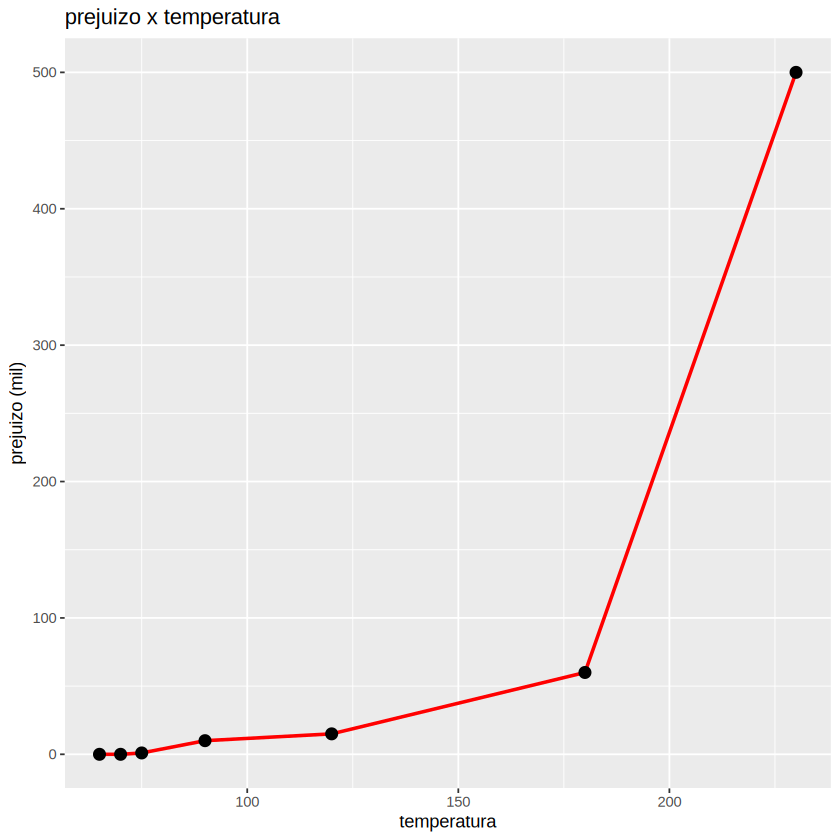

In [15]:
#CASO 1 - Derretimento de 90 GPU por causa de superaquecimento e derretimento nos cabos SATA
#https://www.estadao.com.br/tecmundo/big-techs/243000-minerador-tem-prejuizo-r-500-mil-incendio-placas-de-video/
#Derretimento das placas de video por causa da alta temperatura (não monitorada, gerou um prejuizo de 500 mil)

ggplot(data = NULL , aes(x = c(65, 70, 75, 90, 120, 180, 230), y = c(0, 0, 1, 10, 15, 60, 500))) +
  geom_line(color = "red" , size = 1 ) +
  geom_point(size = 3) +
  labs( title = "prejuizo x temperatura" , x = "temperatura" , y = "prejuizo (mil)")


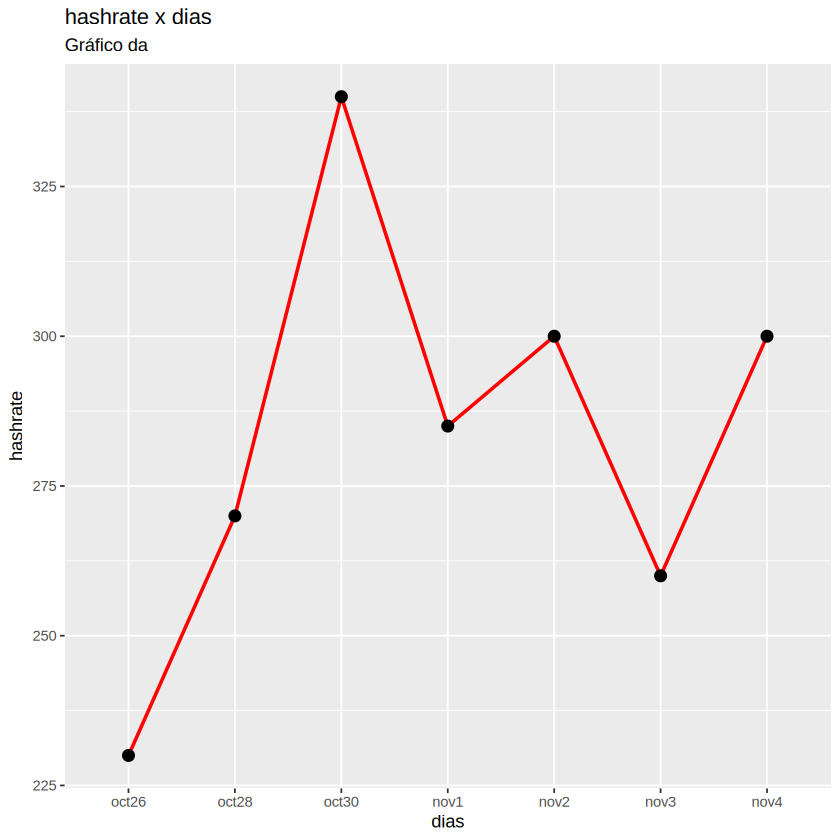

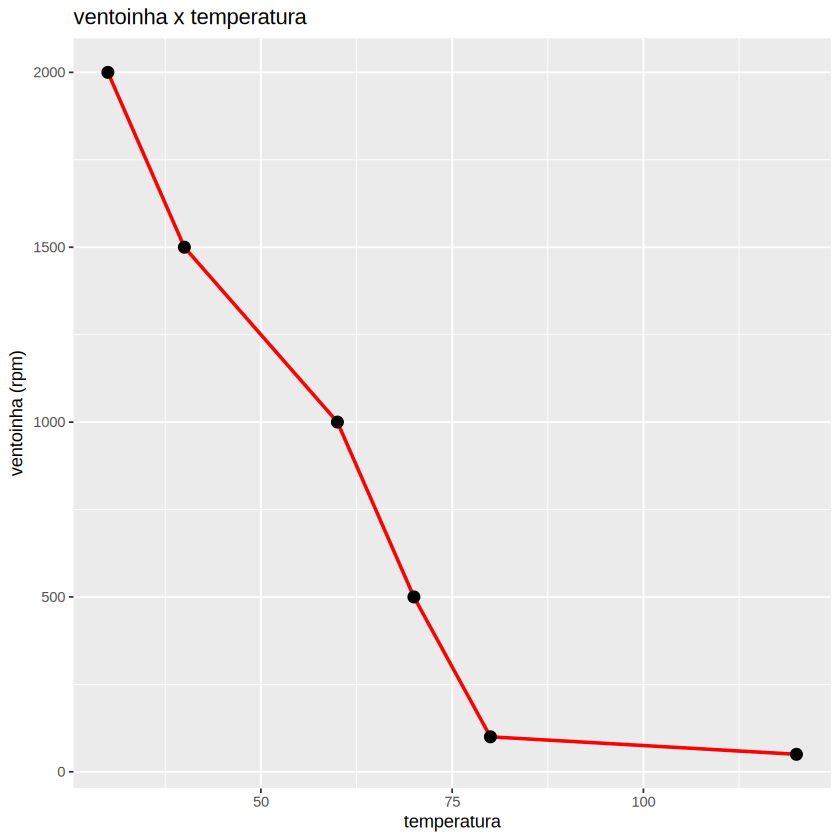

In [16]:
#CASO 2 - Incendio em um fazendo de mineração de bitcoin na Tailândia
#https://qz.com/293418/an-enormous-bitcoin-mine-went-up-in-flames-affecting-the-entire-network
#Incendio causa prejuizo enorme para fazenda de mineração na Tailândia

ggplot(data = NULL, aes(x = factor(c("oct26", "oct28" , "oct30" ,"nov1" , "nov2" , "nov3" , "nov4"), levels = c("oct26", "oct28" , "oct30" ,"nov1" , "nov2" , "nov3" , "nov4")), y = c(230, 270 , 340 , 285 , 300 , 260 ,  300 ) , group = 1)) +
  geom_line(color = "red" , size = 1) +
  geom_point(size = 3) +
  labs(title = "hashrate x dias" , subtitle = "Gráfico da "  , y = "hashrate" , x = "dias")

ggplot(data = NULL, aes(x = c(30 , 40 , 60 , 70 ,80 , 120) , y = c(2000 , 1500 , 1000 , 500 , 100 , 50))) +
  geom_line( color = "red" , size = 1) +
  geom_point(size =3) +
  labs(title = "ventoinha x temperatura" , x = "temperatura" , y = "ventoinha (rpm)")


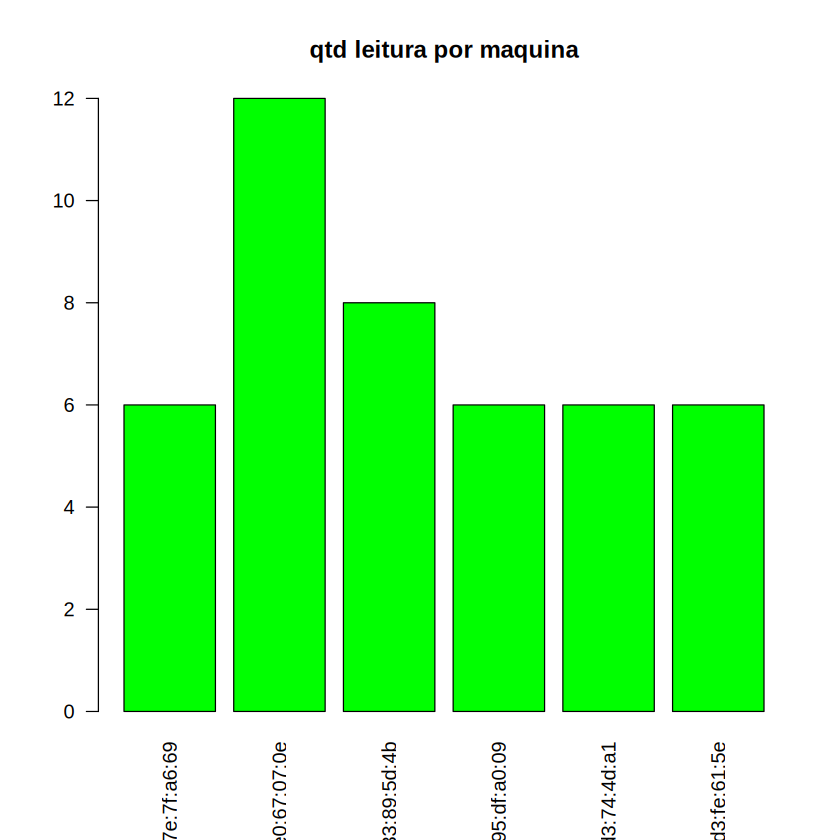

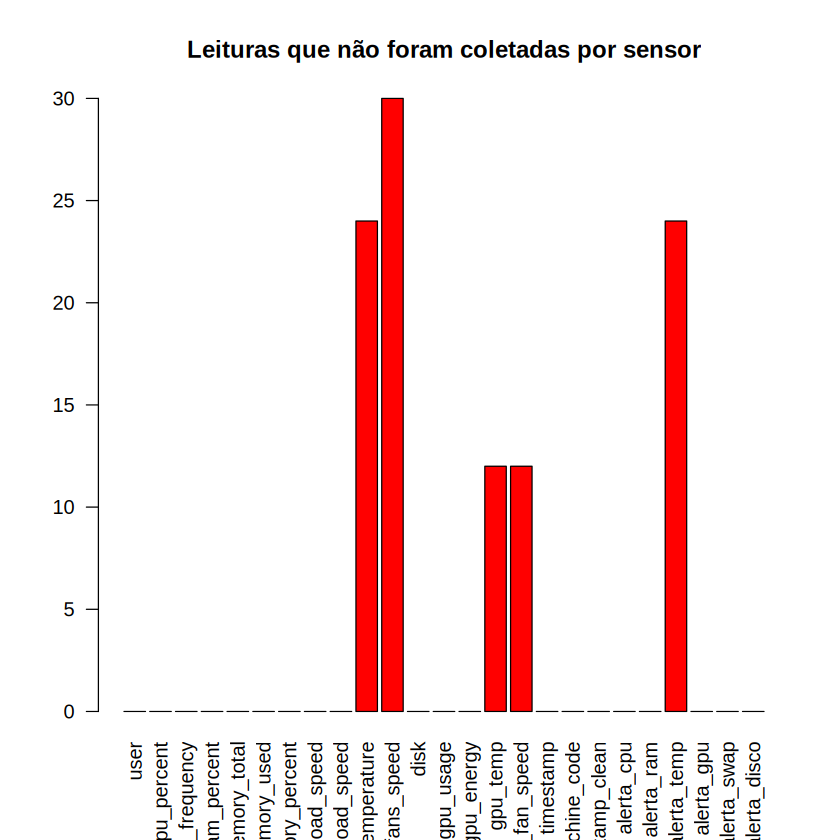

In [69]:
#INICIO ANALISE

#ver se teve padrão no comportamento das leituras
barplot(table(data_geral$user), las = 2, col = "green",
        main = "qtd leitura por maquina")

#vê quantas leituras não foram coletadas por métricas
barplot(colSums(is.na(data_geral)), las = 2, col = "red",
        main = "Leituras que não foram coletadas por sensor")





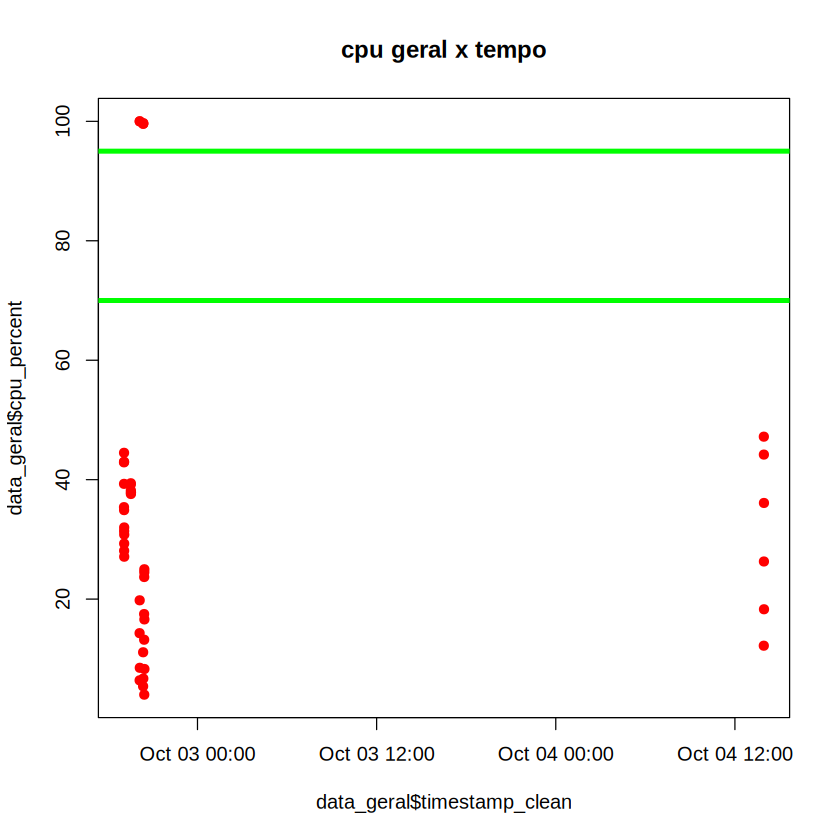

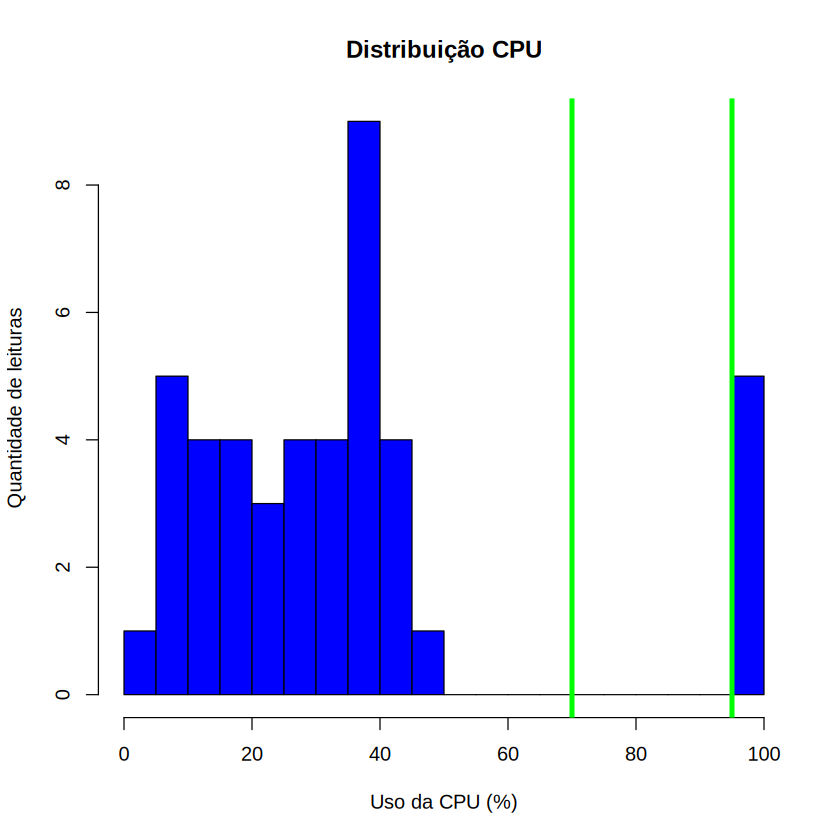

In [23]:
#cpu métricas

#plot de porcentagem de cpu por tempo e a faixa ideal no contexto do projeto
plot(data_geral$timestamp_clean , data_geral$cpu_percent , col = ifelse(data_geral$cpu_percent > 95 | data_geral$cpu_percent < 70, "red", "green") , pch = 19 , main = "cpu geral x tempo")
abline(h = c(70 ,95) , col = "green" , lwd = 4)


#histograma disso
hist(data_geral$cpu_percent, col = "blue", breaks = 20,
     xlim = c(0, 100), main = "Distribuição CPU",
     xlab = "Uso da CPU (%)", ylab = "Quantidade de leituras")
abline(v = c(70, 95), col = "green", lwd = 4)


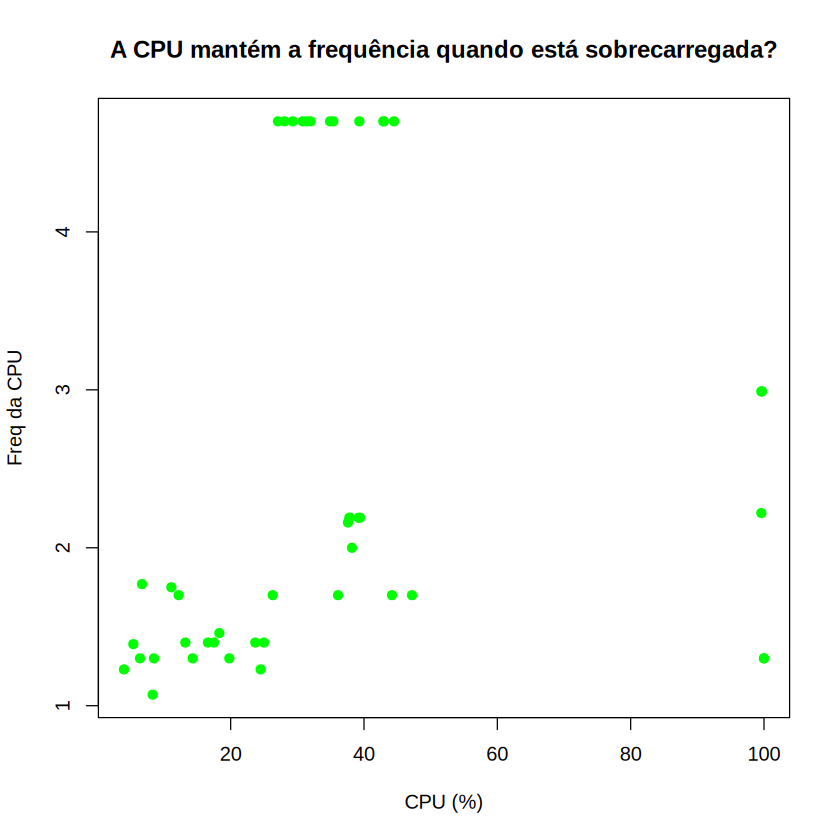

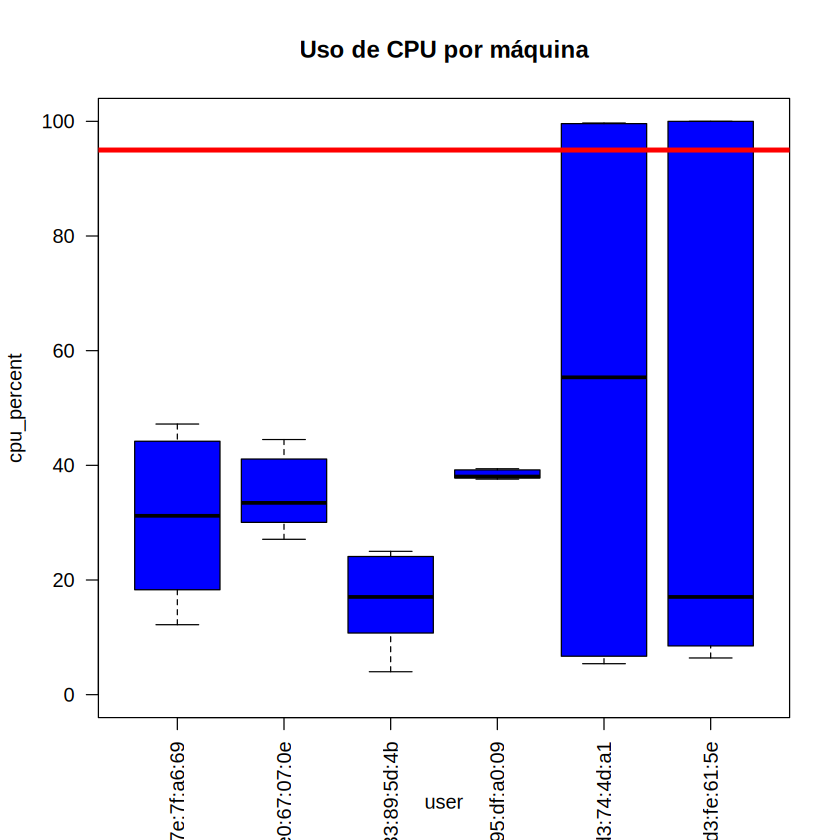

In [24]:

#entendendo possível coorelação entre frequência de cpu e porcentagem, algumas máquinas tem esse padrão
plot(data_geral$cpu_percent, data_geral$cpu_frequency, pch = 19,
     col = "green",
     main = "A CPU mantém a frequência quando está sobrecarregada?",
     xlab = "CPU (%)", ylab = "Freq da CPU")

#boxplot do uso de cpu pra cada usuário
boxplot(cpu_percent ~ user, data = data_geral, las = 2, col = "blue",
        ylim = c(0, 100), main = "Uso de CPU por máquina")
abline(h = 95, col = "red", lwd = 4)

[1] alto       medio      medio      alto       alto       medio     
 [7] medio      medio      medio      medio      medio      medio     
[13] medio      medio      medio      medio      medio      medio     
[19] baixo      baixo      baixo      muito alto muito alto baixo     
[25] baixo      baixo      muito alto muito alto muito alto baixo     
[31] baixo      baixo      medio      baixo      medio      medio     
[37] baixo      baixo      baixo      alto       alto       medio     
[43] medio      baixo     
Levels: baixo < medio < alto < muito alto

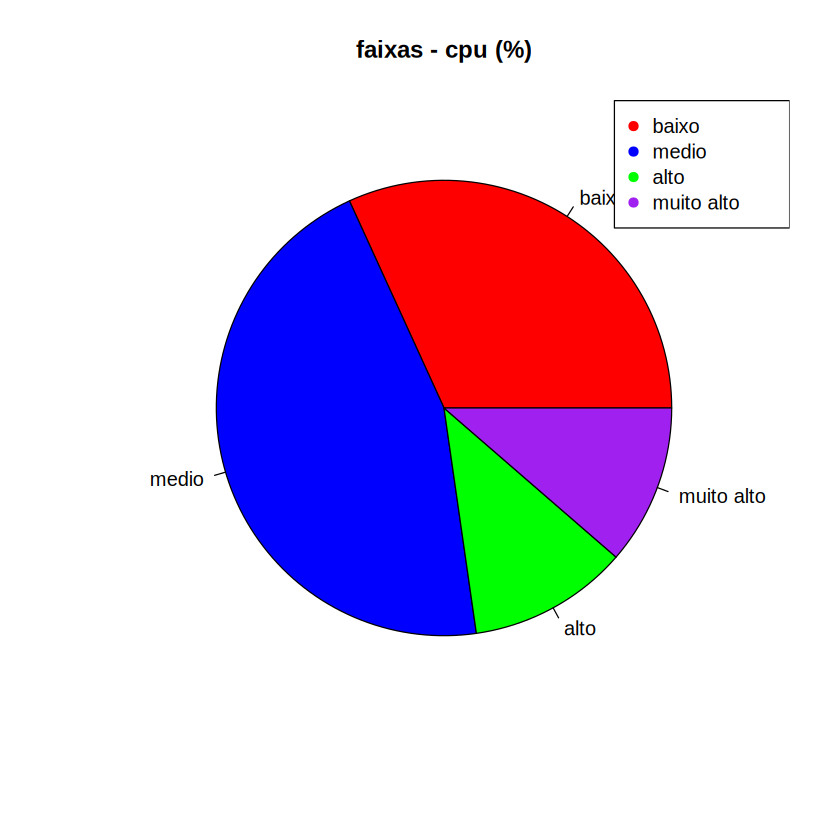

In [25]:
faixas_cpu_per <- cut(data_geral$cpu_percent, breaks = c(0, 20, 40, 90, 100),
                      labels = c("baixo", "medio", "alto", "muito alto"), ordered_result = TRUE)

#com base na leitura das cpus onde entra o nível dessa leitura
pie(table(faixas_cpu_per) , main = "faixas - cpu (%)",  col = c("red" , "blue" , "green" , "purple"))
legend("topright" , legend = c("baixo" , "medio" , "alto" , "muito alto") , col = c("red" , "blue" , "green" , "purple") , pch = 19)



Warning message:
“Use of `data_geral$timestamp_clean` is discouraged.
ℹ Use `timestamp_clean` instead.”
Warning message:
“Use of `data_geral$cpu_percent` is discouraged.
ℹ Use `cpu_percent` instead.”


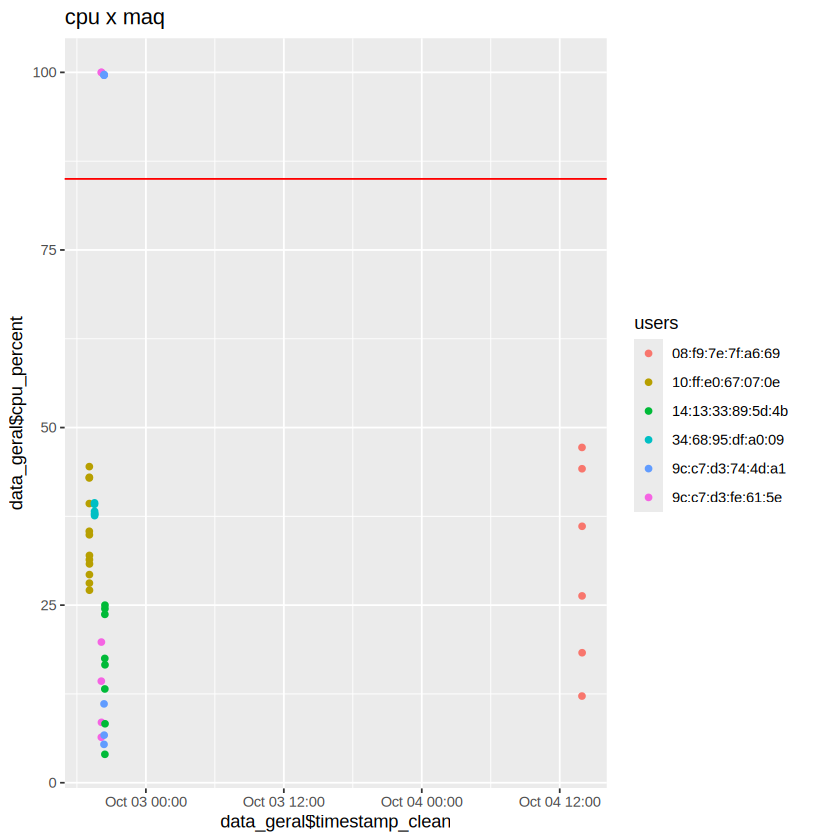

In [27]:

#usando ggplot para mostrar cpu por tempo mas separando por máquina
ggplot(data_geral, aes(data_geral$timestamp_clean, data_geral$cpu_percent, color = user)) +
  geom_point(aes(col = user)) +
  geom_hline(yintercept  = 85, col = "red") +
  labs(
    title = "cpu x maq",
    col = "users"
  )


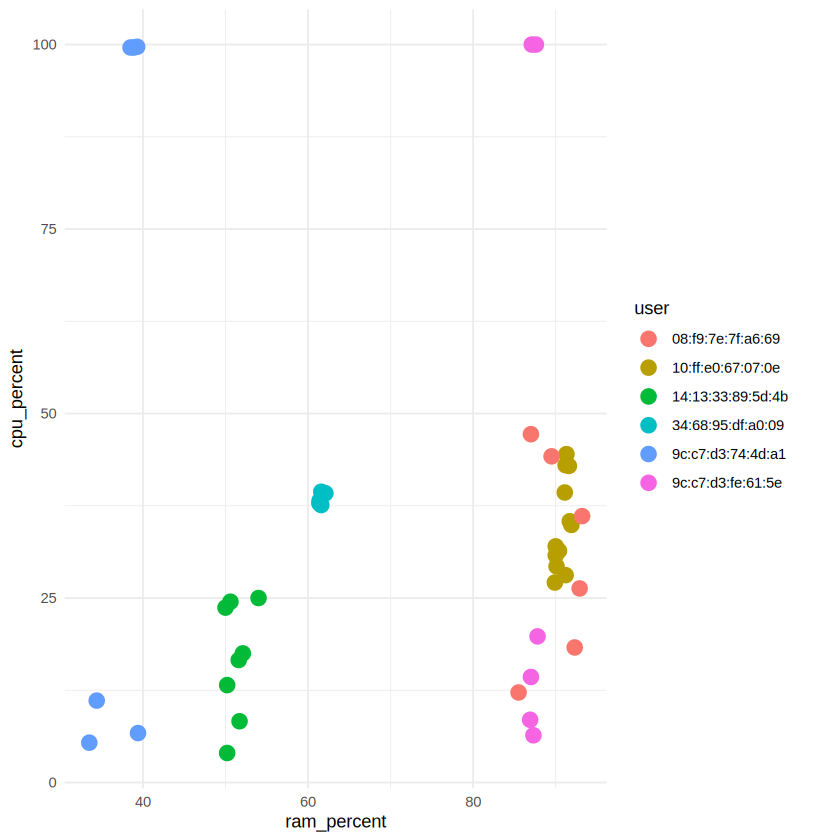

In [75]:
#coorelação de cpu e ram de acordo com usuário
ggplot(data_geral, aes(ram_percent, cpu_percent, color = user)) +
  geom_point(size = 4) +
  theme_minimal()


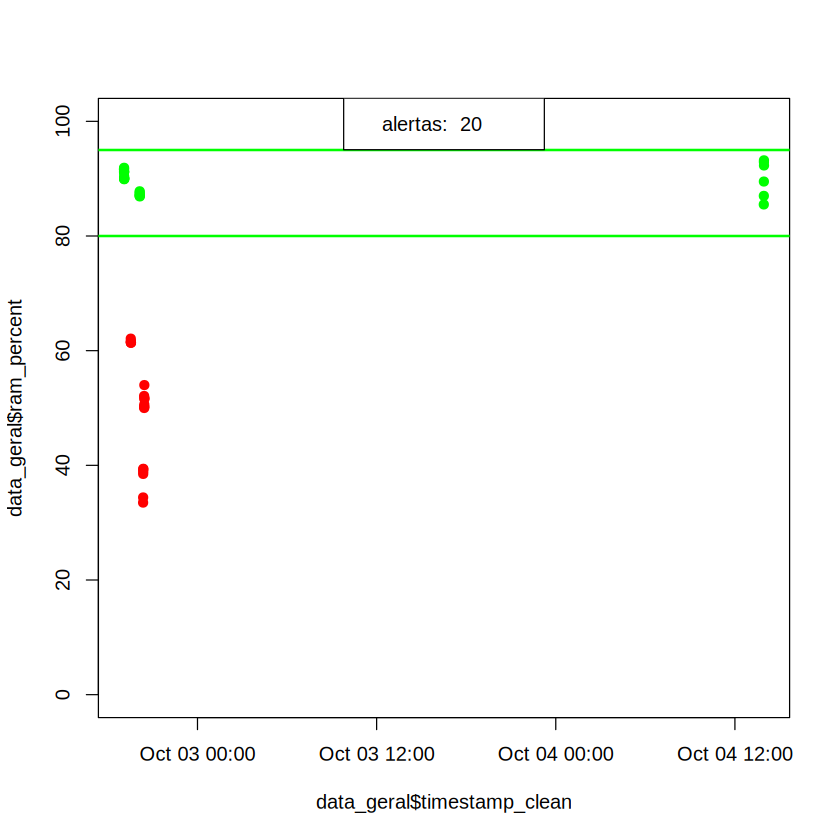

In [30]:
#gráfico variação de ram por tempo
plot(data_geral$timestamp_clean , data_geral$ram_percent , col = ifelse(data_geral$ram_percent < 80 | data_geral$ram_percent > 95 , "red" , "green") , pch = 19  , ylim = c(0 , 100))
abline(h = c(80 , 95) , col = "green" , lwd = 2)
legend("top" , legend = paste("alertas: " , sum(data_geral$alerta_ram)))




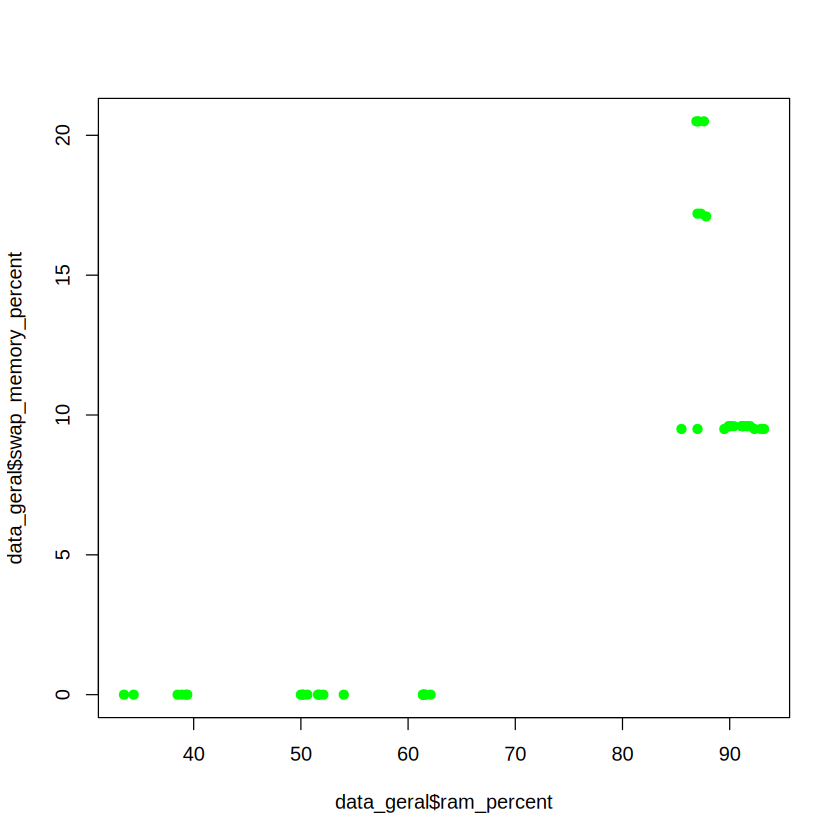

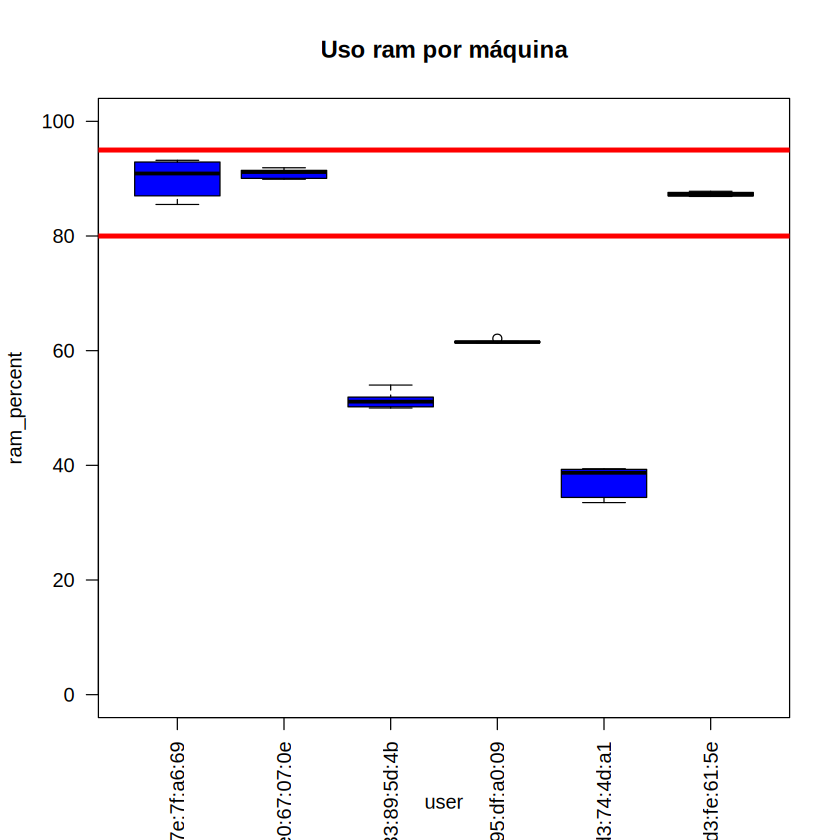

In [39]:
#plot pra ver possível coorelação entre ram e swap
plot(data_geral$ram_percent , data_geral$swap_memory_percent , col = "green", pch = 19 )

#boxplot da ram por usuário
boxplot(ram_percent ~ user, data = data_geral, las = 2, col = "blue",
        ylim = c(0, 100), main = "Uso ram por máquina")
abline(h = c(80 , 95), col = "red", lwd = 4)

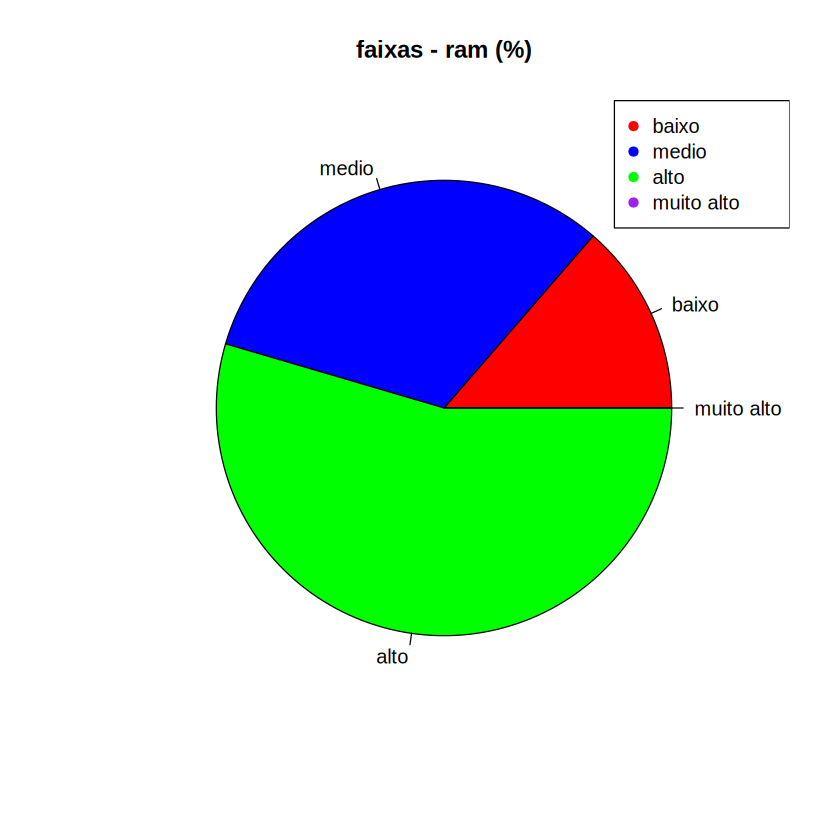

In [32]:
#nivel de ram de acordo com leitura
faixas_ram_per <- cut(data_geral$ram_percent, breaks = c(0, 40, 70, 95, 100),
                      labels = c("baixo", "medio", "alto", "muito alto"), ordered_result = TRUE)
pie(table(faixas_ram_per) , main = "faixas - ram (%)",  col = c("red" , "blue" , "green" , "purple"))
legend("topright" , legend = c("baixo" , "medio" , "alto" , "muito alto") , col = c("red" , "blue" , "green" , "purple") , pch = 19)



Warning message:
“Use of `data_geral$ram_percent` is discouraged.
ℹ Use `ram_percent` instead.”
Warning message:
“Use of `data_geral$swap_memory_percent` is discouraged.
ℹ Use `swap_memory_percent` instead.”


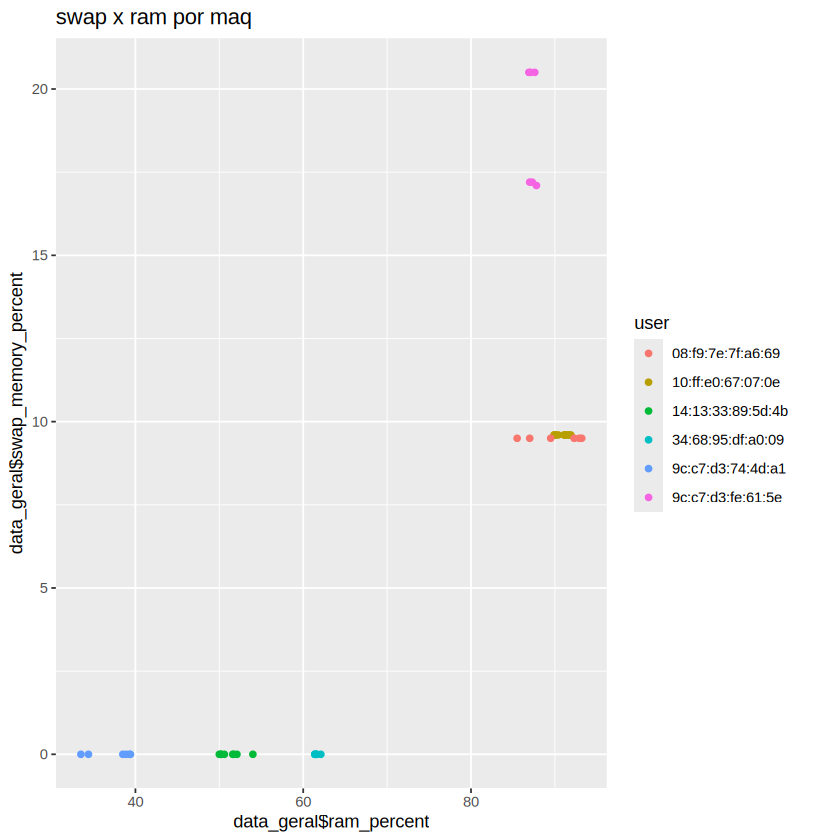

In [34]:
#swap x ram por máquina
ggplot(data_geral, aes(data_geral$ram_percent, data_geral$swap_memory_percent, color = user)) +
  geom_point() +
  labs(title = "swap x ram por maq")



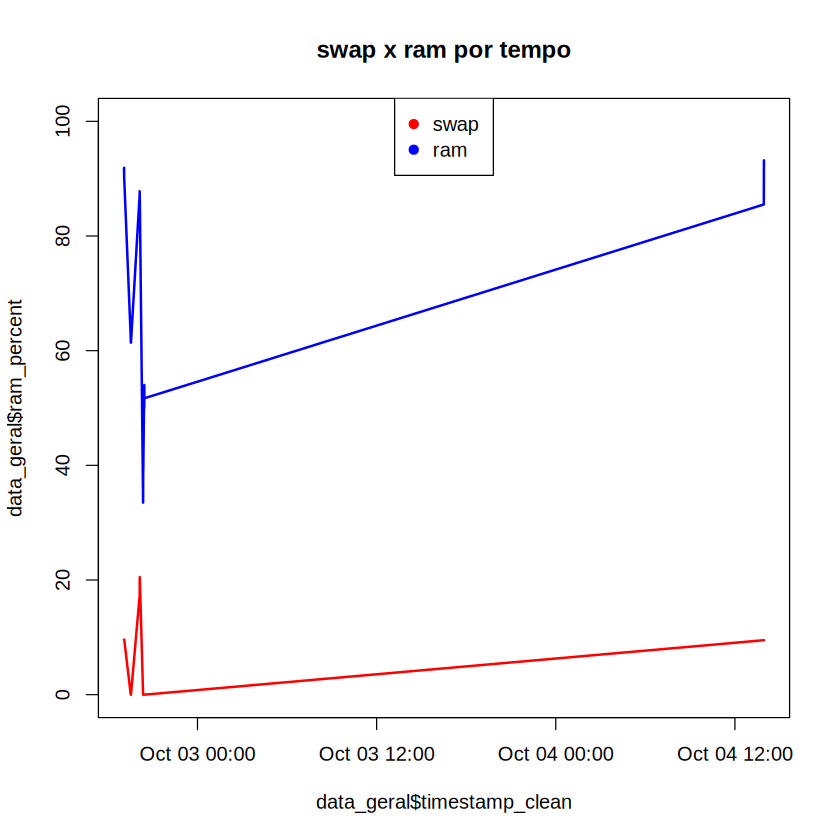

In [35]:
#swap e ram por tempo
plot(data_geral$timestamp_clean , data_geral$ram_percent , type = "l" , ylim = c(0 ,100) , col = "blue" , lwd = 2 , main = "swap x ram por tempo")
lines(data_geral$timestamp_clean , data_geral$swap_memory_percent , col = "red" , lwd = 2)
legend("top" , legend = c("swap" , "ram") , col = c("red" , "blue") , pch = 19)


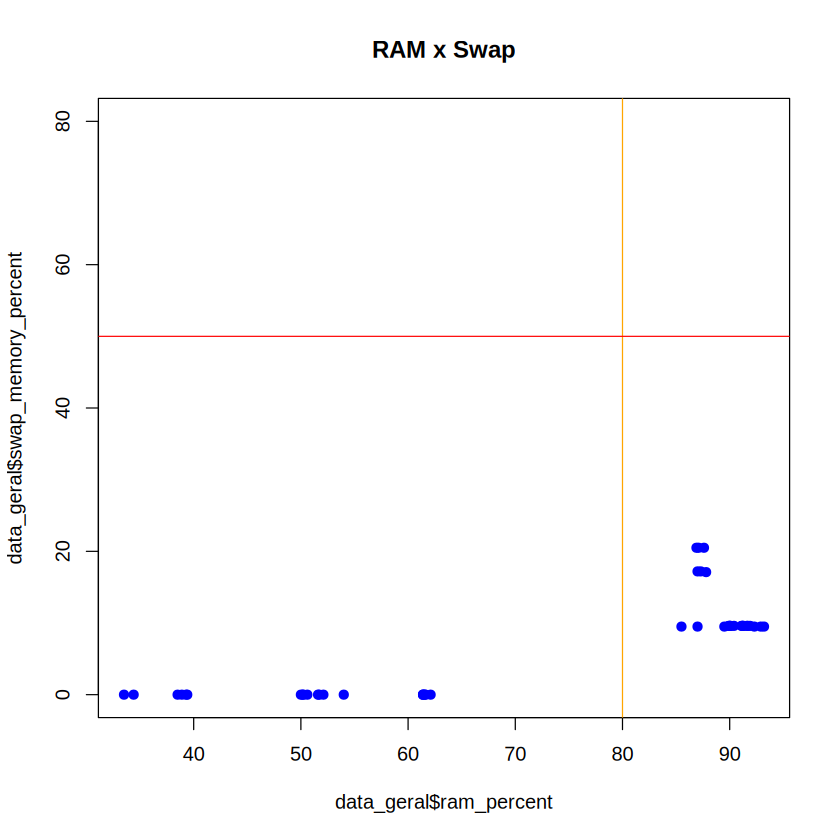

In [40]:
#mostra mesmo gráfico de ram e swap mas colocando as linhas de limiares para ambas
plot(data_geral$ram_percent, data_geral$swap_memory_percent, , ylim = c(0, 80), pch = 19, col = "blue",
     main = "RAM x Swap")
abline(v = 80, col = "orange")
abline(h = 50, col = "red")




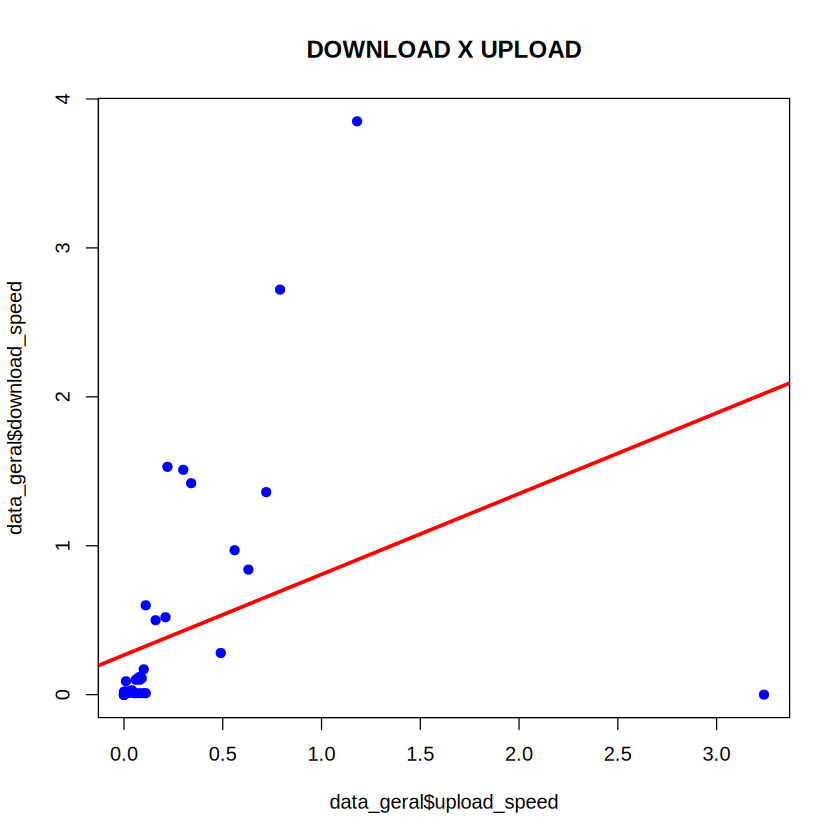

In [41]:
#rede
#usando plot para mostrar possível coorelação e colocando a linha de regressão linear
plot(data_geral$upload_speed , data_geral$download_speed , col = "blue" , pch = 19 , main = "DOWNLOAD X UPLOAD")
abline(lm(data_geral$download_speed ~ data_geral$upload_speed) , col = "red" , lwd = 3)


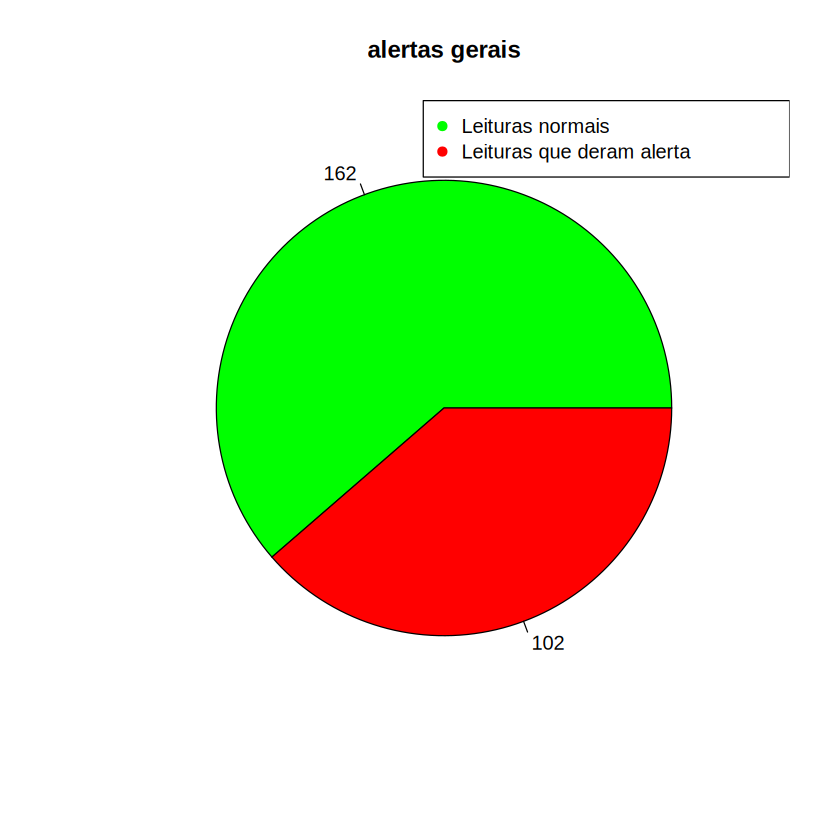

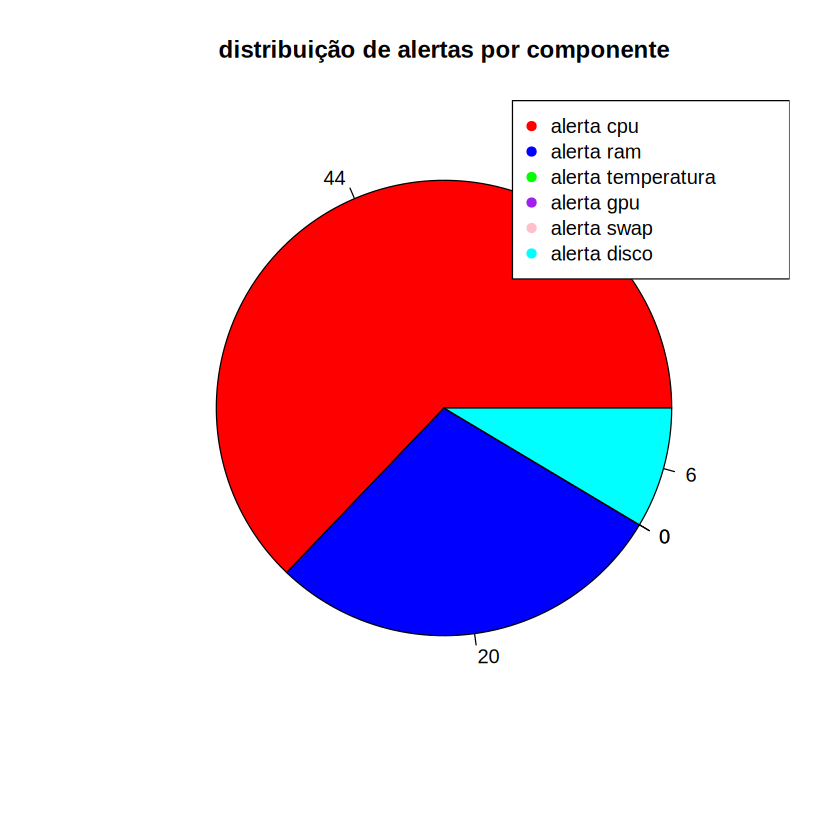

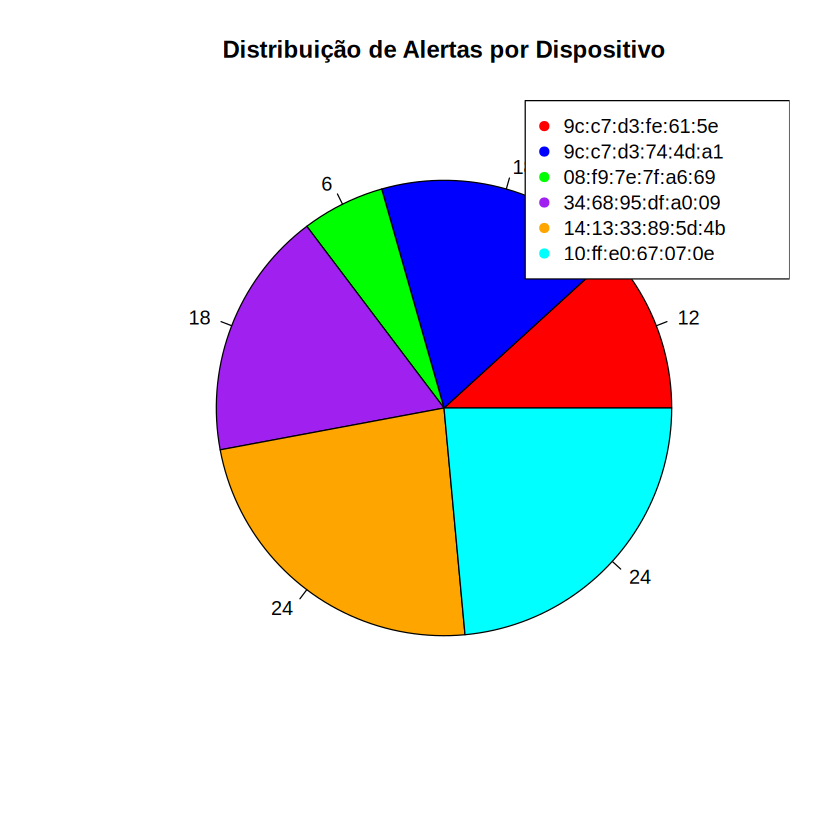

In [49]:
#alertas

#das leituras quantas delas deram alertas
pie(c((contador_base - contadorgeral), contadorgeral), col = c("green", "red"),labels = c(leituras_normais, contadorgeral),main = "alertas gerais")
legend("topright", legend = c("Leituras normais", "Leituras que deram alerta"), col = c("green", "red"), pch = 19)


#distribuição dos alertas por componente
pie(c(sum(data_geral$alerta_cpu) , sum(data_geral$alerta_ram) , sum(data_geral$alerta_temp , na.rm = TRUE) ,sum(data_geral$alerta_gpu) , sum(data_geral$alerta_swap) , sum(data_geral$alerta_disco) ) , col = c("red" , "blue" , "green" , "purple" , "pink" , "cyan") , labels = c( sum(data_geral$alerta_cpu) , sum(data_geral$alerta_ram) , sum(data_geral$alerta_temp) ,sum(data_geral$alerta_gpu) , sum(data_geral$alerta_swap) , sum(data_geral$alerta_disco)) , main = "distribuição de alertas por componente" )
legend("topright", legend = c("alerta cpu" , "alerta ram" , "alerta temperatura" , "alerta gpu" , "alerta swap" , "alerta disco"), col = c("red" , "blue" , "green"  , "purple" , "pink" , "cyan") , pch = 19)


totais <- c()
for(m in df_alertas$user) {
  totais[m] <- sum(df_alertas$Freq[df_alertas$user == m])
}

#distribuição dos alertas de acordo com o dispositivo
pie(totais,
  col = c("red", "blue", "green", "purple", "orange", "cyan"),
  main = "Distribuição de Alertas por Dispositivo",
  labels = totais
)
legend("topright" , legend = names(totais) , col = c("red", "blue", "green", "purple", "orange", "cyan") , pch = 19)



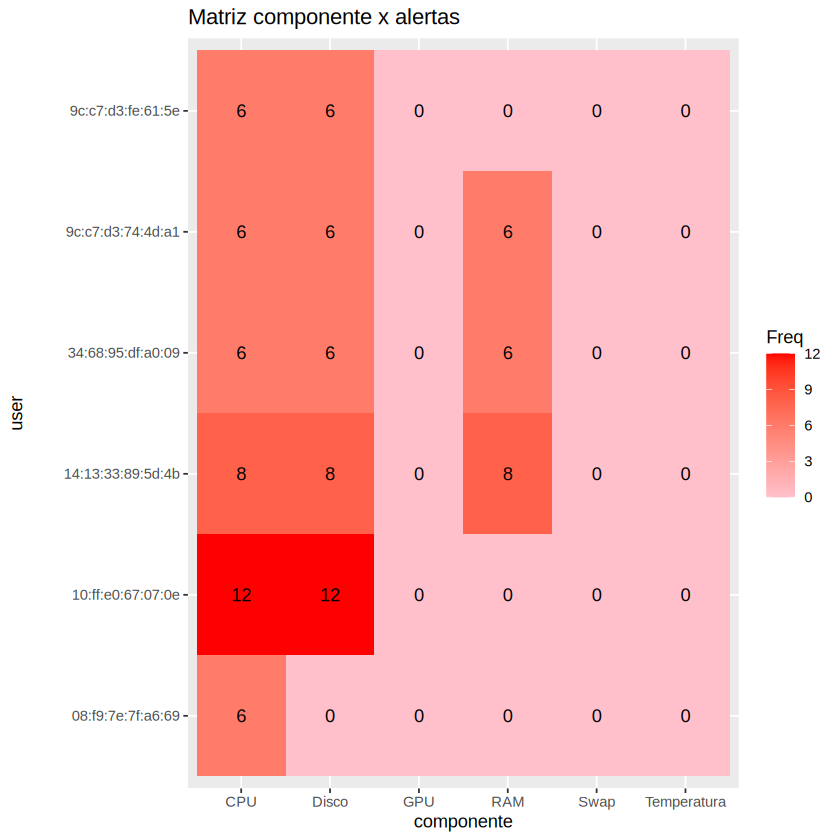

In [50]:
#mostrando por meio de uma matriz a frequência de alertas por componente
ggplot(df_alertas, aes(componente, user, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq)) +
  scale_fill_gradient(low = "pink", high = "red") +
  labs(title = "Matriz componente x alertas")


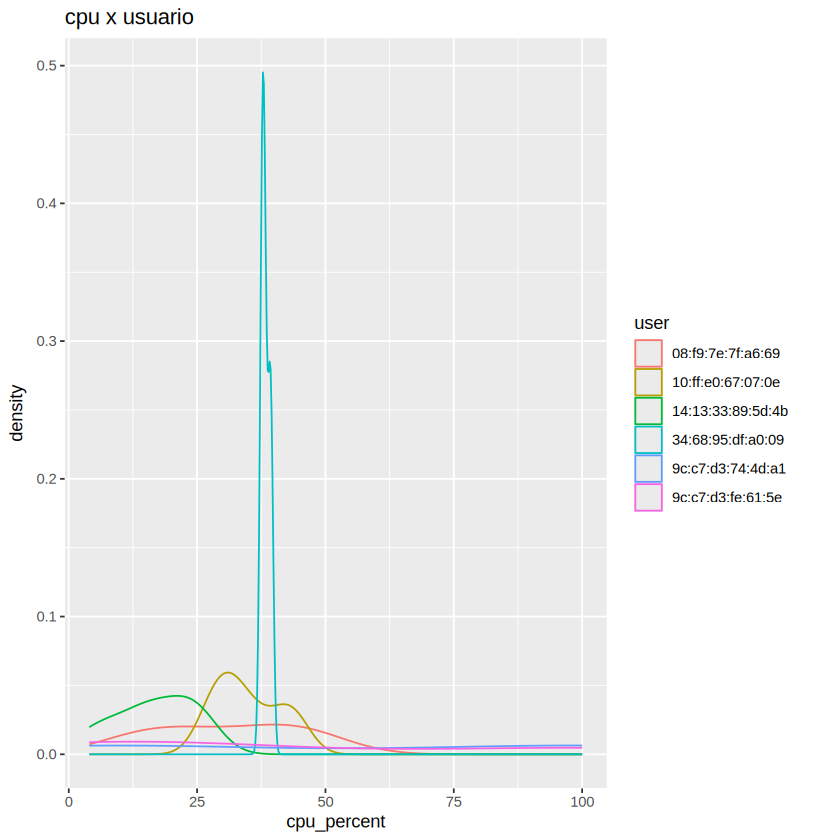

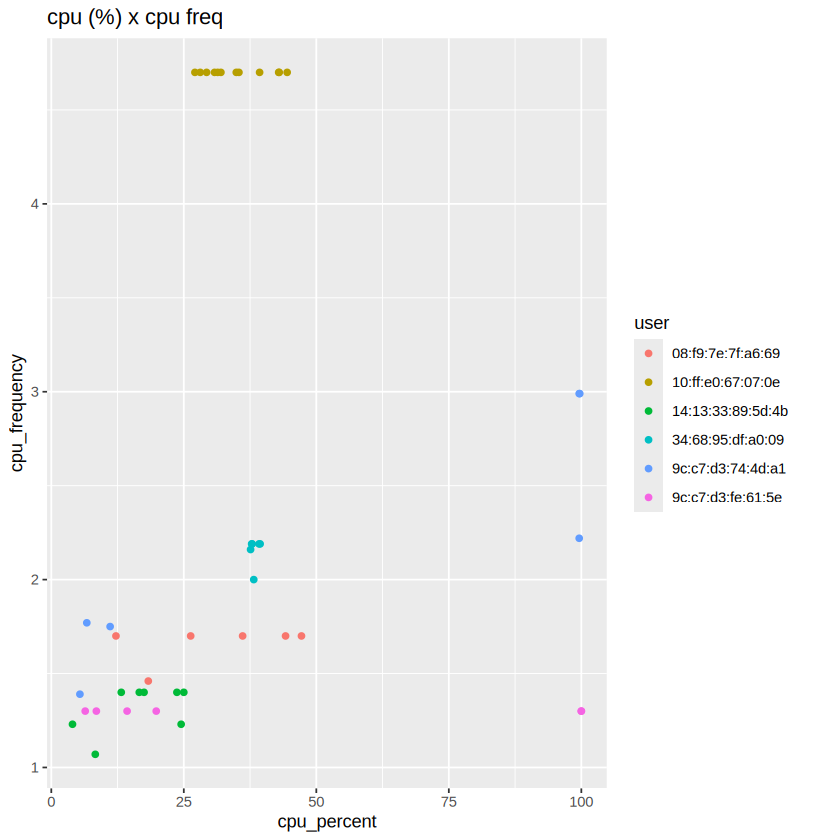

In [58]:
#gráfico de densidade de cpu por usuário
ggplot(data_geral, aes(cpu_percent, col = user)) +
  geom_density() +
  labs(title = "cpu x usuario")

#gráfico frequência x porcentagem de cpu por usuário
ggplot(data_geral, aes(cpu_percent, cpu_frequency, color = user) ) +
  geom_point() +
  labs(title = "cpu (%) x cpu freq")



`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 6”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 6”
Warning message in sqrt(sum.squares/one.delta):
“NaNs produced”
Warning message in stats::qt(level/2 + 0.5, pred$df):
“NaNs produced”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.0006”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.0206”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  4.4058e-17”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.0001”
Warning message in predLoess(object$y, object$x, newx = if (is.null

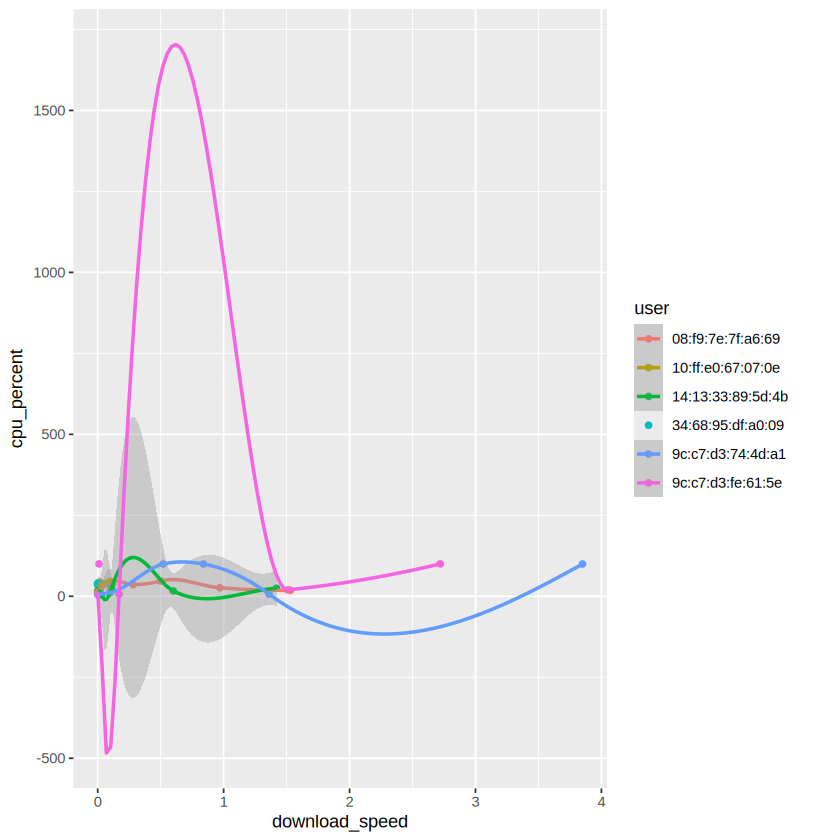

In [59]:
#gráfico de download e porcentagem de cpu para analisar cooreção em alguma máquina
ggplot(data_geral, aes(download_speed, cpu_percent, color = user)) +
  geom_point() + geom_smooth()



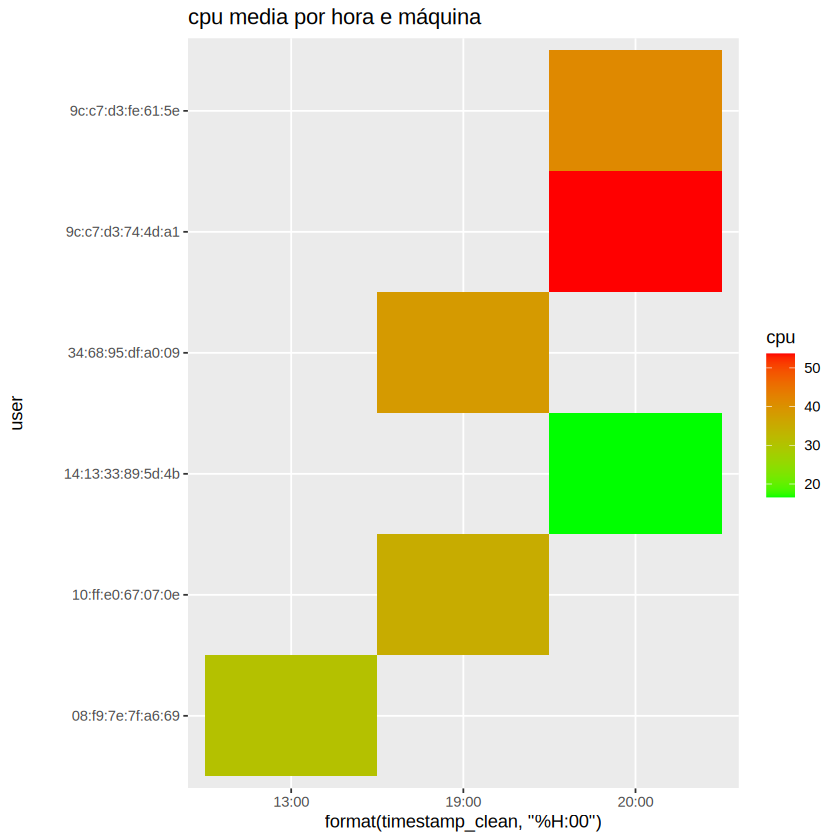

In [60]:
#pega as horas e analisa a cpu média de cada máquina e coloca uma cor com base no nível
ggplot(data_geral, aes(format(timestamp_clean, "%H:00"),user, fill = ave(cpu_percent, user, format(timestamp_clean, "%H:00")))) +
  geom_tile() +
  scale_fill_gradient(low = "green", high = "red") +
  labs(title = "cpu media por hora e máquina" , fill = "cpu")


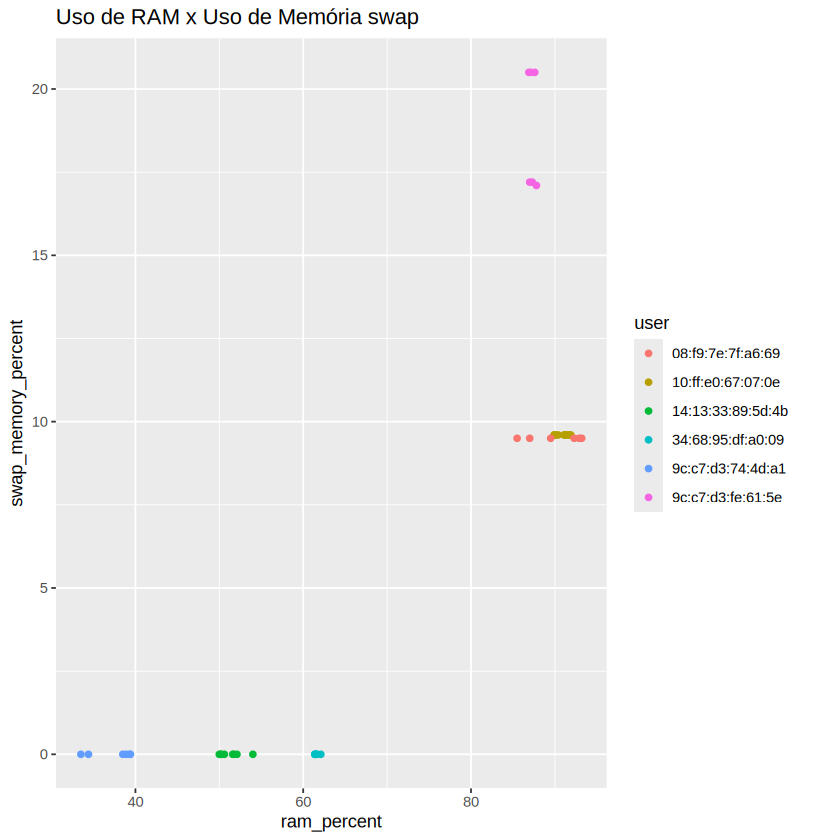

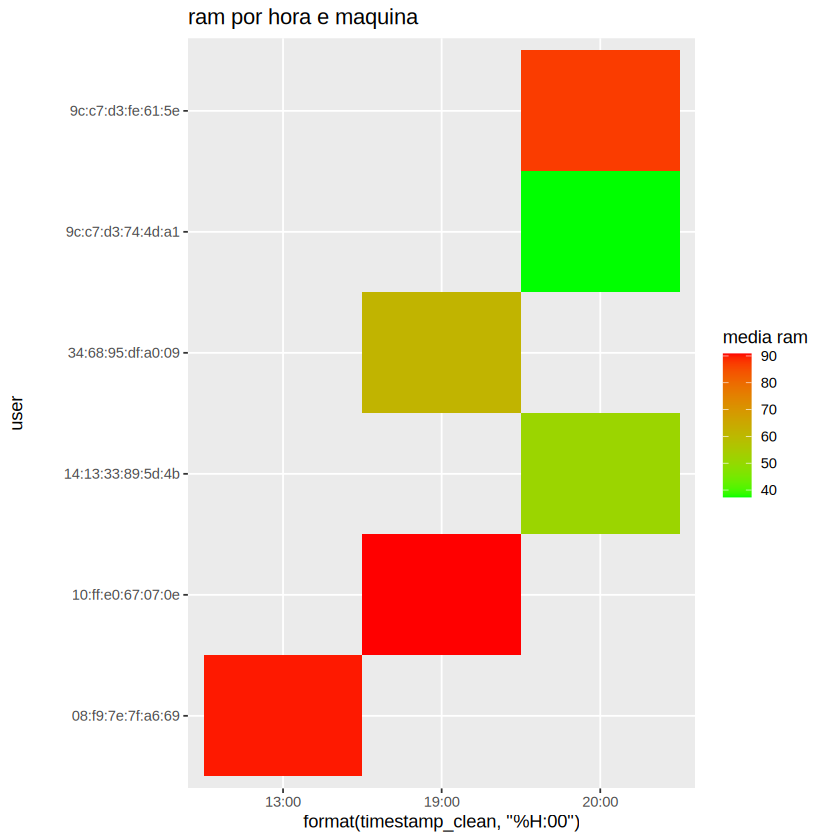

In [61]:
#ram x swap para analisar coorelação entre máquinas
ggplot(data_geral, aes(x = ram_percent, y = swap_memory_percent, color = user)) +
  geom_point() +
  labs(title = "Uso de RAM x Uso de Memória swap")

#pega as horas e analisa ram e preenche com base no nível
ggplot(data_geral, aes(format(timestamp_clean, "%H:00"), user, fill = ave(ram_percent, user,  format(timestamp_clean, "%H:00") ))) +
  geom_tile() +
  scale_fill_gradient(low = "green" , high = "red") +
  labs(title = "ram por hora e maquina" , fill = "media ram")



`geom_smooth()` using formula = 'y ~ x'


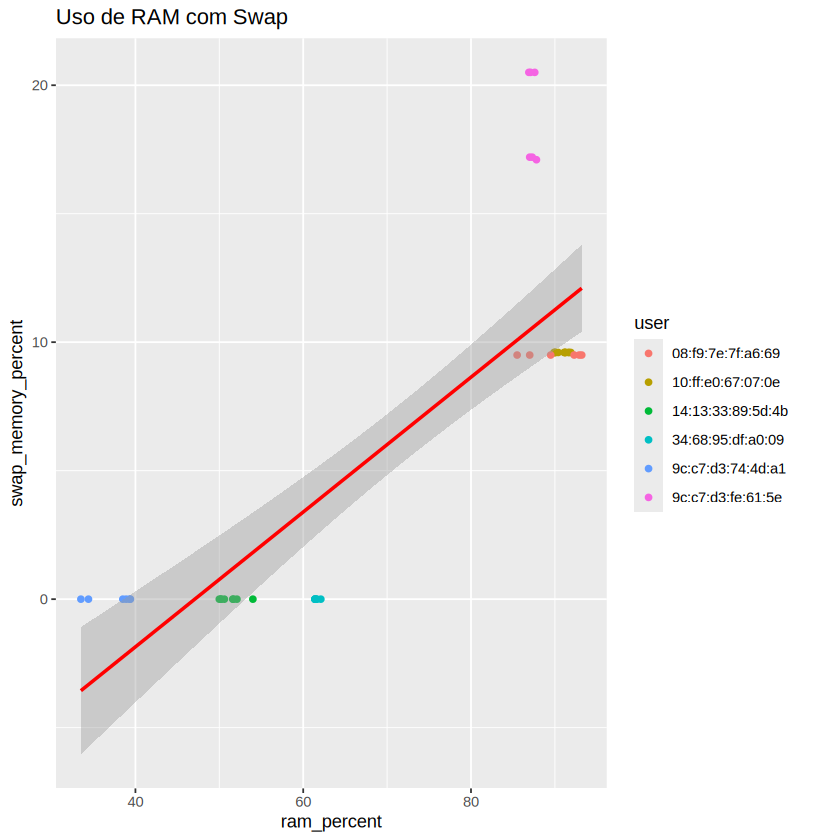

In [73]:
#ram x swap coorelação e linha de regressão linear
ggplot(data_geral, aes(ram_percent, swap_memory_percent, color = user)) +
  geom_point() +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Uso de RAM com Swap",
  )

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 6”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 6”
Warning message in sqrt(sum.squares/one.delta):
“NaNs produced”
Warning message in stats::qt(level/2 + 0.5, pred$df):
“NaNs produced”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -5e-05”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  2.5e-09”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -5e-05”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood 

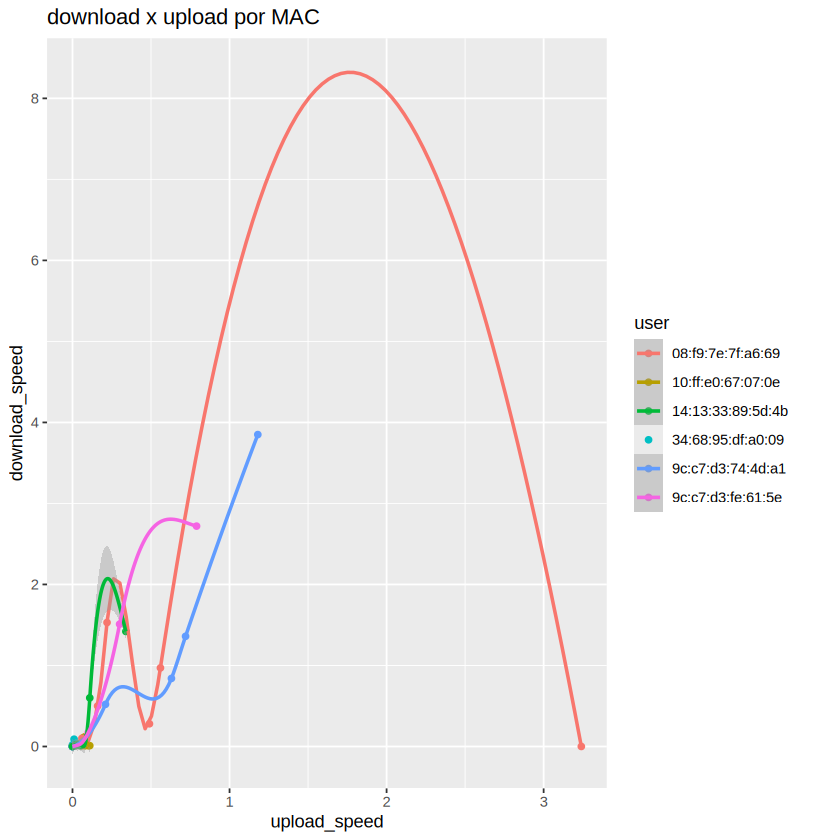

In [62]:
#download x upload por máquina para ver coorelação
ggplot(data_geral, aes(upload_speed, download_speed, color = user )) +
  geom_point() +
  geom_smooth() +
  labs(title = "download x upload por MAC")


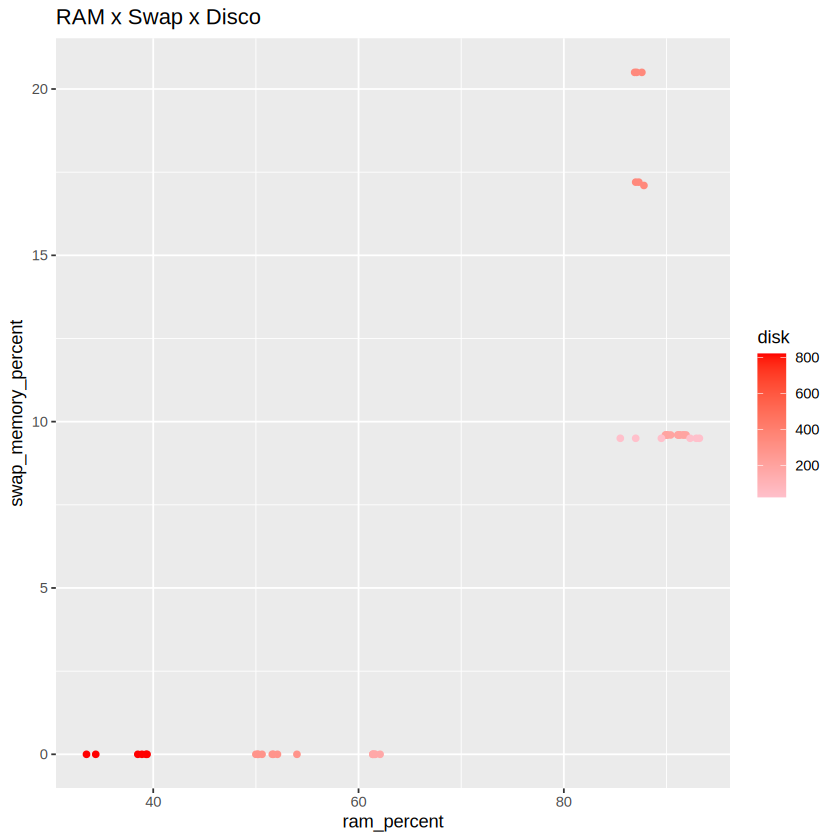

In [63]:
#analisando 3 coorelção em conjunto disco , ram e swap
ggplot(data_geral, aes(ram_percent, swap_memory_percent, color = disk)) +
  geom_point() +
  scale_color_gradient(low = "pink", high = "red") +
  labs(
    title = "RAM x Swap x Disco")


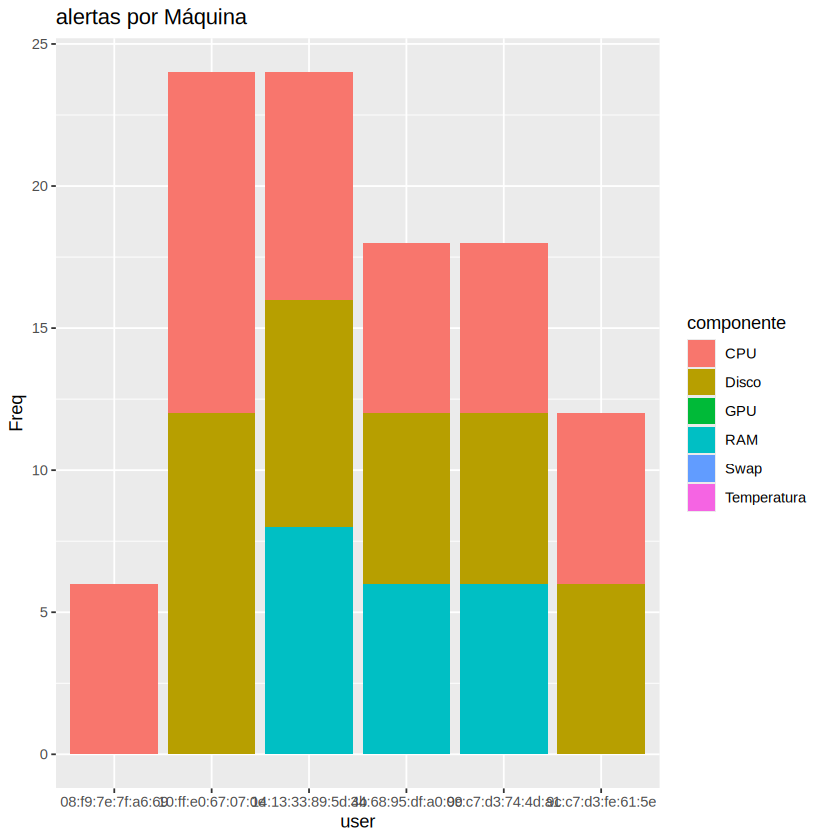

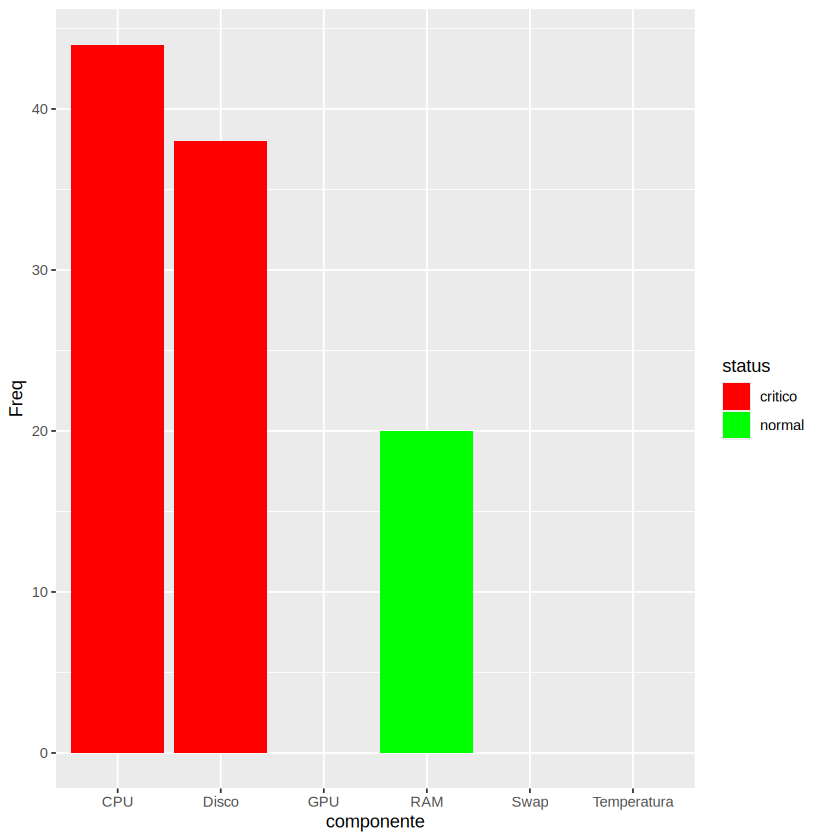

In [65]:
#distribuição de alertas por componente de cada máquina
ggplot(df_alertas, aes(user, Freq, fill = componente)) +
  geom_col() +
  labs(
    title = "alertas por Máquina"
  )

#vê a quantidade de alertas que o componente possui e vê se está em um nível prejudicial ou não
  ggplot(df_alertas, aes(componente, Freq,
                       fill = ifelse(ave(Freq, componente, FUN = sum) > 30, "critico", "normal"))) +geom_col() + scale_fill_manual(values = c("critico" = "red", "normal" = "green")) +
labs(fill = "status")



Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_point()`).”


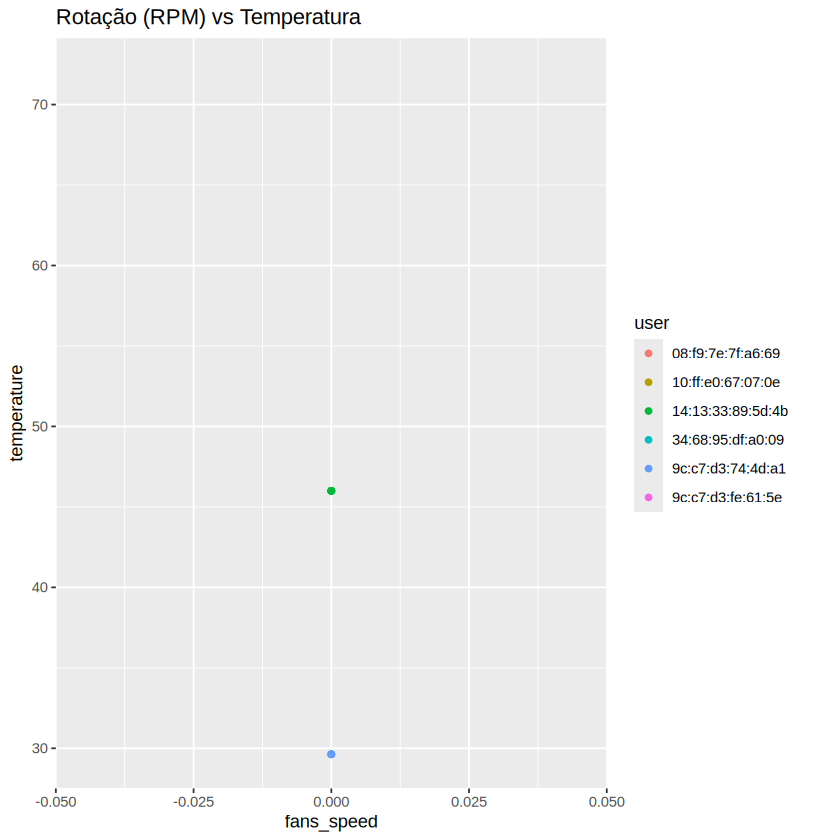

In [66]:
#analisa quais máquinas tem temperatura e ventoinha
ggplot(data_geral, aes(fans_speed, temperature, color = user)) +
  geom_point() +
  labs(title = "Rotação (RPM) vs Temperatura")


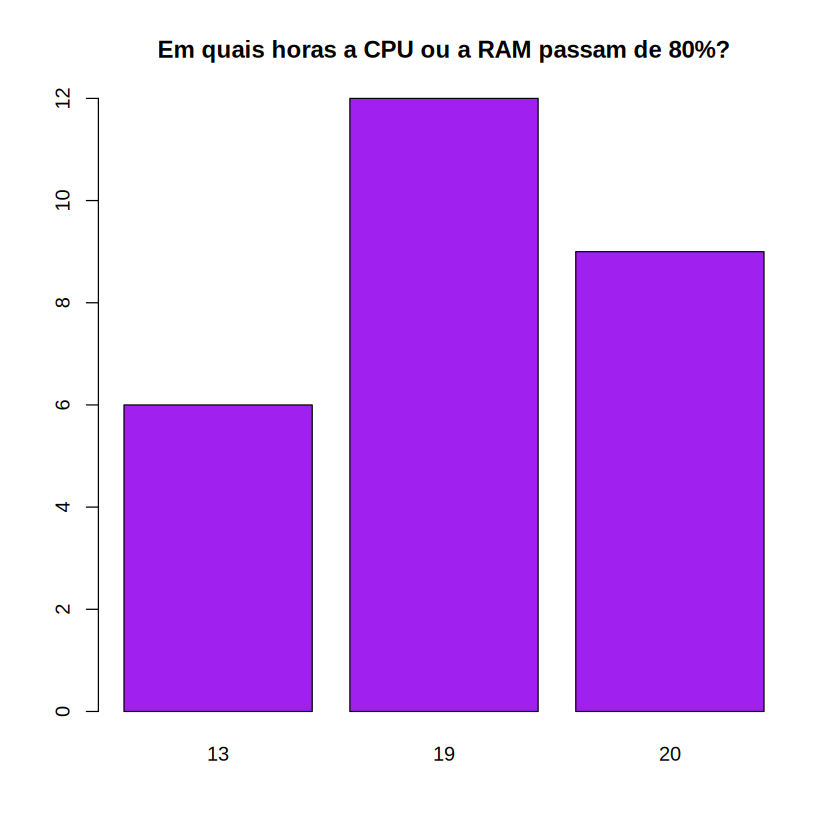

In [68]:
#dentro dessas horas, quantas leituras cpu ou ram ficaram maior que 80%
barplot(table(format(data_geral$timestamp_clean[which(data_geral$cpu_percent > 80 | data_geral$ram_percent > 80)], "%H")),
        col = "purple",
        main = "Em quais horas a CPU ou a RAM passam de 80%?")




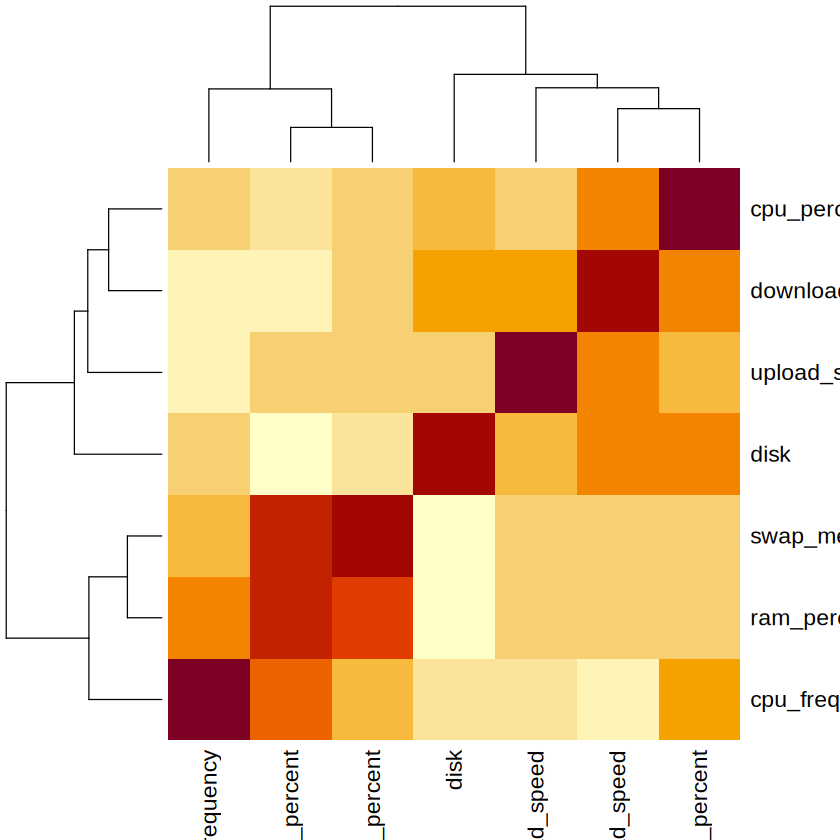

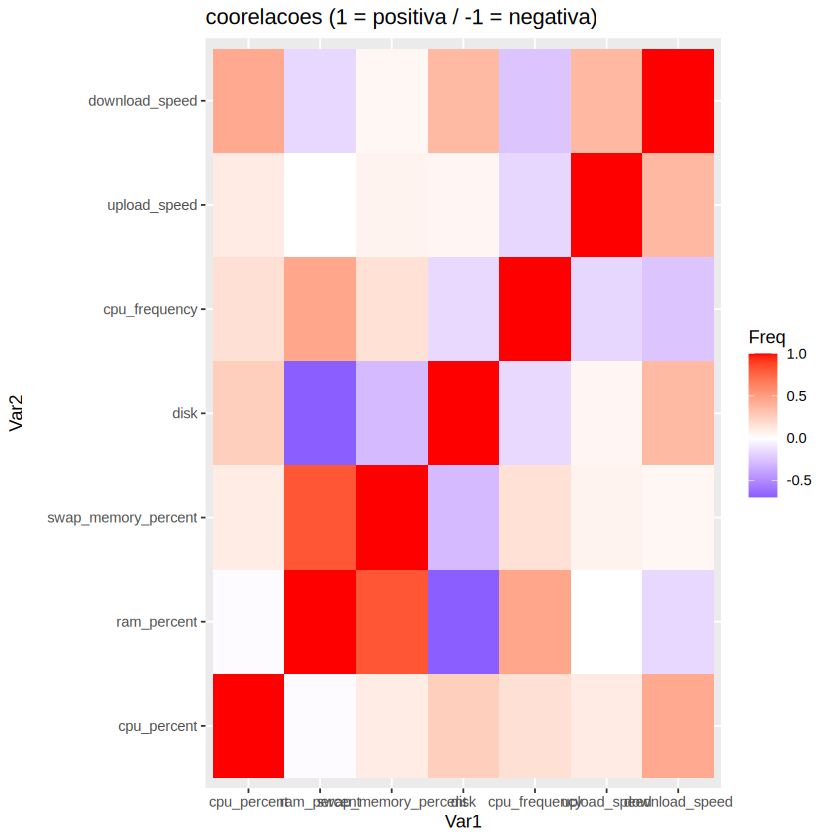

In [71]:
#mapa de coorelação positiva
heatmap(cor(data_geral[c("cpu_percent", "ram_percent", "swap_memory_percent", "disk", "cpu_frequency", "upload_speed", "download_speed")]))

#mapa que analisa tanta coorelação positiva quanto negativa
ggplot(as.data.frame(as.table(cor(data_geral[ c("cpu_percent", "ram_percent", "swap_memory_percent", "disk", "cpu_frequency", "upload_speed", "download_speed")], use = "pairwise.complete.obs"))),
       aes(Var1, Var2, fill = Freq)) +
  geom_tile() +
  labs(title = "coorelacoes (1 = positiva / -1 = negativa)" ) +
  scale_fill_gradient2(low = "blue", high = "red")
